# Encoder transform analysis — NWC_ql on Llama-3-8B q_proj rows

Same data and model as `plot_encoder_function.ipynb`:
- **Model**: `nwc_ql` checkpoint (M=16, encdim=512, Q=4) trained on Llama-3-8B weight blocks
- **Data**: layer-10 self-attn `q_proj.weight`, per-column std-normalized, reshaped to 16-dim blocks

Compare four transforms acting on 16-dim blocks:
1. **No transform** — identity
2. **Scaling** — per-channel std normalization
3. **Random Hadamard Rotation (RHR)** — 16×16 H · diag(±1)
4. **Learned** — NWC encoder `g_a` with quality embedding (q_level=1)

Analyses (mirroring `plot_encoder_function_jacobian.ipynb`):
- §3–§5 Local Jacobian (orthogonality / entry distribution / energy mixing / covariance)
- §6 Latent collection
- §7 Distribution shaping (histogram / sorted std / |corr| heatmap)
- §8 Information reallocation (variance spectrum, cumulative energy)
- §9 Quantization-noise robustness (RD sweep with per-channel uniform quantizer)
- §10 2-D toy figure


## 0. Setup — load NWC_ql model and Llama-3-8B

In [1]:
import os
os.environ['CUDA_VISIBLE_DEVICES'] = '6'

import argparse, sys, json, math, glob
from pathlib import Path
from collections import OrderedDict

import torch
import numpy as np
import matplotlib.pyplot as plt

# Path setup (matches plot_encoder_function.ipynb)
notebook_dir = os.path.dirname(os.path.abspath('__file__'))
project_root = os.path.abspath(os.path.join(notebook_dir, '..'))
if project_root not in sys.path:
    sys.path.append(project_root)
project_root2 = os.path.abspath(os.path.join(os.getcwd(), '..', 'comp_lm_qtip'))
if project_root2 not in sys.path:
    sys.path.append(project_root2)

import lib.utils as utils
from NWC.models import get_model
from transformers import AutoModelForCausalLM

torch.manual_seed(0); np.random.seed(0)
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
DTYPE  = torch.float32
print('device', DEVICE, '/ CUDA_VISIBLE_DEVICES =', os.environ.get('CUDA_VISIBLE_DEVICES'))


I0507 10:47:59.132216 904228 utils.py:148] Note: detected 128 virtual cores but NumExpr set to maximum of 64, check "NUMEXPR_MAX_THREADS" environment variable.


I0507 10:47:59.134156 904228 utils.py:151] Note: NumExpr detected 128 cores but "NUMEXPR_MAX_THREADS" not set, so enforcing safe limit of 16.


I0507 10:47:59.134890 904228 utils.py:164] NumExpr defaulting to 16 threads.


W0507 10:47:59.370504 904228 warnings.py:109] /opt/conda/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm



W0507 10:48:00.796394 904228 warnings.py:109] /opt/conda/lib/python3.10/site-packages/torchvision/io/image.py:13: UserWarning: Failed to load image Python extension: '/opt/conda/lib/python3.10/site-packages/torchvision/image.so: undefined symbol: _ZN3c1017RegisterOperatorsD1Ev'If you don't plan on using image functionality from `torchvision.io`, you can ignore this warning. Otherwise, there might be something wrong with your environment. Did you have `libjpeg` or `libpng` installed before building `torchvision` from source?
  warn(



W0507 10:48:01.779727 904228 warnings.py:109] /opt/conda/lib/python3.10/site-packages/compressai/models/video/google.py:353: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  @amp.autocast(enabled=False)



Importing from quanto will be deprecated in v4.47. Please install optimum-quanto instrad `pip install optimum-quanto`


W0507 10:48:23.974200 904228 warnings.py:109] /opt/conda/lib/python3.10/site-packages/pydantic/_internal/_generate_schema.py:2249: UnsupportedFieldAttributeWarning: The 'repr' attribute with value False was provided to the `Field()` function, which has no effect in the context it was used. 'repr' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. This may have happened because an `Annotated` type alias using the `type` statement was used, or if the `Field()` function was attached to a single member of a union type.
  warnings.warn(



W0507 10:48:23.976625 904228 warnings.py:109] /opt/conda/lib/python3.10/site-packages/pydantic/_internal/_generate_schema.py:2249: UnsupportedFieldAttributeWarning: The 'frozen' attribute with value True was provided to the `Field()` function, which has no effect in the context it was used. 'frozen' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. This may have happened because an `Annotated` type alias using the `type` statement was used, or if the `Field()` function was attached to a single member of a union type.
  warnings.warn(



device cuda / CUDA_VISIBLE_DEVICES = 6


In [2]:
# Load NWC_ql checkpoint (closest existing match to plot_encoder_function.ipynb's path:
# same dataset / architecture / M=16 / Q=4 / lmbda=300; the original best_loss_5.32101 file
# was rotated out, so we use the debug_module variant best_loss_5.35718 which is functionally equivalent.)
class Config:
    def __init__(self, **entries): self.__dict__.update(entries)

def load_comp_model(comp_model_path):
    cfg_p = os.path.join(os.path.dirname(comp_model_path), 'config.json')
    with open(cfg_p, 'r', encoding='utf-8') as fh:
        cfg = Config(**json.load(fh))
    if cfg.architecture == 'nwc_ql' and not hasattr(cfg, 'Q'):
        cfg.Q = 4
    if not hasattr(cfg, 'no_layernorm'):
        cfg.no_layernorm = False
    shift, scale = torch.empty(()), torch.empty(())
    comp_model = get_model(cfg.architecture, cfg, scale=scale, shift=shift)
    comp_model.config = cfg
    ckpt = torch.load(comp_model_path, weights_only=False)
    scale, shift = torch.ones(1), torch.zeros(1)
    comp_model.load_state_dict(ckpt['state_dict'], strict=False)
    try:
        comp_model.scale.copy_(scale); comp_model.shift.copy_(shift)
    except Exception:
        comp_model.scale = scale; comp_model.shift = shift
    comp_model.eval()
    comp_model.update()
    return comp_model

# NWC_PATH = ('/home/jgryu/workspace/weight_compression/NWC/checkpoint/nwc_ql/'
#             'block_seq_ql_random_scaler_meta-llama--Meta-Llama-3-8B__col_1024_gaussian_padding.pt/'
#             'debug_module_rdloss_ql_size16_encdim512_M16_Q4_R0_m0_batch_size2048_total_iter200000_lr0.0001_seed100/'
#             'lmbda300_/best_loss_model_loss_5.35718_bpp_5.602_MSE_0.00307_total_iter_47500.pth.tar')

NWC_PATH = "/home/jgryu/workspace/weight_compression/NWC/checkpoint2/nwc_ql/block_seq_ql_random_scaler_meta-llama--Meta-Llama-3-8B__col_1024_gaussian_padding.pt/M16/lmbda300_rdloss_ql_size16_encdim512_M16_Q4_R0_m0_batch_size2048_total_iter200000_lr0.0001_seed100/best_loss_model_loss_5.32101_bpp_5.72603_MSE_0.00289_total_iter_95000.pth.tar"

nwc = load_comp_model(NWC_PATH).to(DEVICE).eval()
print('NWC loaded:', 'input_size=', nwc.input_size, 'M=', nwc.M, 'dim_encoder=', nwc.dim_encoder, 'Q=', nwc.Q)
print(nwc.scale, nwc.shift)
BLOCK_DIM = int(nwc.input_size)
M_DIM     = int(nwc.M)
Q_LEVEL   = 1                          # default quality level used in original notebook


NWC loaded: input_size= 16 M= 16 dim_encoder= 512 Q= 4
tensor([1.], device='cuda:0') tensor([0.], device='cuda:0')


In [3]:
# Load Llama-3-8B and extract layer-10 q_proj weight (RAW — no per-column std normalization)
BASE_HF = '/home/jgryu/workspace/weight_compression/Wparam_dataset/hf_model/meta-llama--Meta-Llama-3-8B'
llama = AutoModelForCausalLM.from_pretrained(BASE_HF, torch_dtype='auto', low_cpu_mem_usage=True, local_files_only=True)
W_full = llama.model.layers[10].self_attn.q_proj.weight.detach().float()      # (4096, 4096)

# NOTE: per-column std normalization has been REMOVED.
# Raw weights have non-uniform per-column scale → 16-dim blocks become a
# scale-mixture (heavy-tailed marginal), so transform-coding effects can show.
print('W_full', tuple(W_full.shape), 'mean', float(W_full.mean()), 'std', float(W_full.std()))
print('   per-column std  min', float(W_full.std(dim=0).min()),
      ' max', float(W_full.std(dim=0).max()),
      ' median', float(W_full.std(dim=0).median()))
del llama
torch.cuda.empty_cache()


Loading checkpoint shards:   0%|          | 0/7 [00:00<?, ?it/s]

Loading checkpoint shards:  14%|█▍        | 1/7 [00:00<00:01,  5.02it/s]

Loading checkpoint shards:  29%|██▊       | 2/7 [00:00<00:00,  5.41it/s]

Loading checkpoint shards:  43%|████▎     | 3/7 [00:00<00:00,  5.71it/s]

Loading checkpoint shards:  57%|█████▋    | 4/7 [00:00<00:00,  5.85it/s]

Loading checkpoint shards:  71%|███████▏  | 5/7 [00:00<00:00,  5.95it/s]

Loading checkpoint shards:  86%|████████▌ | 6/7 [00:01<00:00,  6.01it/s]

Loading checkpoint shards: 100%|██████████| 7/7 [00:01<00:00,  6.07it/s]

Loading checkpoint shards: 100%|██████████| 7/7 [00:01<00:00,  5.88it/s]

W_full (4096, 4096) mean 2.3763618628436234e-06 std 0.017250822857022285
   per-column std  min 0.009721467271447182  max 0.02197856642305851  median 0.017217999324202538


## 1. Sample 16-dim blocks
Same reshape as the codec's forward: `W.T.reshape(-1, 16)` (columns become row-blocks of 16).
Per-column std normalization gives a unit-std distribution per channel — the format the encoder was trained on.

In [4]:
# Reshape exactly like the codec: (m, n) -> (n, m) -> (-1, 16)
W_full = W_full / W_full.std()
W_blocks_all = W_full.T.reshape(-1, BLOCK_DIM).contiguous()                   # (N_blocks, 16)
print('W_blocks_all', tuple(W_blocks_all.shape))

N_SAMPLES = 8192
g = torch.Generator().manual_seed(0)
idx = torch.randperm(W_blocks_all.shape[0], generator=g)[:N_SAMPLES]
X_LLAMA = W_blocks_all[idx].to(DEVICE)                                        # (N_SAMPLES, 16)

# Gaussian reference (16-dim, unit std) for comparison
X_GAUSS = torch.randn(N_SAMPLES, BLOCK_DIM, generator=g).to(DEVICE)

print('X_LLAMA', tuple(X_LLAMA.shape), 'mean', float(X_LLAMA.mean()), 'std', float(X_LLAMA.std()))
print('X_GAUSS', tuple(X_GAUSS.shape), 'mean', float(X_GAUSS.mean()), 'std', float(X_GAUSS.std()))


W_blocks_all (1048576, 16)
X_LLAMA (8192, 16) mean 0.0008092985954135656 std 0.9953436255455017
X_GAUSS (8192, 16) mean 0.0001788334921002388 std 0.9993736743927002


## 2. Define the four transforms
All map `(B, 16) -> (B, 16)`.

In [5]:
def make_identity_transform():
    return (lambda x: x.clone())

def make_scaling_transform(X_ref):
    std = X_ref.float().std(dim=0).clamp_min(1e-9).to(DEVICE)
    def f(x): return x / std.unsqueeze(0)
    return f

def hadamard_matrix(n: int):
    if (n & (n - 1)) != 0:
        raise ValueError(f'n must be power of 2, got {n}')
    H = torch.tensor([[1.0]])
    while H.shape[0] < n:
        H = torch.cat([torch.cat([H, H], dim=1),
                       torch.cat([H, -H], dim=1)], dim=0)
    return H / math.sqrt(n)

def make_rht_transform(dim=BLOCK_DIM, seed=0):
    g = torch.Generator().manual_seed(seed)
    diag = (torch.randint(0, 2, (dim,), generator=g).mul(2).sub(1)).float().to(DEVICE)
    H = hadamard_matrix(dim).to(DEVICE)
    def f(x): return (x * diag.unsqueeze(0)) @ H.T
    return f

def make_learned_transform(model, q_level=Q_LEVEL):
    enc = model.g_a
    def f(x):
        # x: (B, 16) -> add a leading dim so encoder sees (1, B, 16)
        x_in = x.unsqueeze(0).contiguous()
        ql = torch.full((1, x.shape[0]), q_level, dtype=torch.long, device=x.device)
        q_embed = model._get_q_embed(q_input=ql, reference=x_in)
        y = enc(x_in, q_embed)            # (1, B, M=16)
        return y.squeeze(0)
    return f

TRANSFORMS = OrderedDict()
TRANSFORMS['no_transform'] = make_identity_transform()
TRANSFORMS['scaling']      = make_scaling_transform(X_LLAMA)
TRANSFORMS['rht']          = make_rht_transform(dim=BLOCK_DIM, seed=0)
TRANSFORMS['learned']      = make_learned_transform(nwc, q_level=Q_LEVEL)
print('Transforms:', list(TRANSFORMS.keys()))


Transforms: ['no_transform', 'scaling', 'rht', 'learned']


## 3. Local Jacobian computation (16×16, dense)
Block dim is small enough for `torch.func.jacrev` on the full 16×16 Jacobian.

In [6]:
from torch.func import jacrev

def jacobian_full(f, x_anchor):
    def f_one(z): return f(z.unsqueeze(0)).squeeze(0)
    return jacrev(f_one)(x_anchor)

def compute_jacobian(name, f, x_anchor):
    D = x_anchor.shape[0]
    if name == 'no_transform':
        return torch.eye(D, device=x_anchor.device)
    if name == 'scaling':
        scale = f(torch.ones_like(x_anchor).unsqueeze(0))[0]
        return torch.diag(scale)
    if name in ('rht', 'learned'):
        return jacobian_full(f, x_anchor)
    raise ValueError(name)


## 4. Metrics: orthogonality / entry distribution / energy mixing / covariance

In [7]:
@torch.no_grad()
def orthogonality_metric(J: torch.Tensor) -> dict:
    D = J.shape[0]
    G = J.T @ J
    alpha = float(torch.trace(G).item()) / D
    diff  = G - alpha * torch.eye(D, device=J.device)
    return {
        'alpha': alpha,
        'frob_diff_rel': float(torch.linalg.norm(diff).item()) /
                         max(float(torch.linalg.norm(alpha * torch.eye(D, device=J.device)).item()), 1e-12),
    }

@torch.no_grad()
def entry_distribution_metric(J: torch.Tensor) -> dict:
    A = J.abs()
    row_mean = A.mean(dim=1).clamp_min(1e-12)
    row_max  = A.max(dim=1).values
    ratio    = row_max / row_mean
    return {'max_to_mean_median': float(ratio.median().item()),
            'max_to_mean_mean':   float(ratio.mean().item()),
            'A_flat': A.flatten().cpu().numpy()}

@torch.no_grad()
def energy_mixing_metric(J: torch.Tensor) -> dict:
    A = J.abs()
    col_sum  = A.sum(dim=0)
    col_l2sq = (A ** 2).sum(dim=0).clamp_min(1e-12)
    pr = (col_sum ** 2) / col_l2sq
    return {'participation_median': float(pr.median().item()),
            'participation_mean':   float(pr.mean().item()),
            'pr_per_col': pr.cpu().numpy()}

@torch.no_grad()
def covariance_metrics(X_in, X_out):
    def cov_stats(X):
        Xc = X - X.mean(dim=0, keepdim=True)
        C  = (Xc.T @ Xc) / (X.shape[0] - 1)
        eig = torch.linalg.eigvalsh(C).clamp_min(1e-12)
        diag = torch.diag(C)
        off  = C - torch.diag(diag)
        return {'cond':     float((eig.max() / eig.min()).item()),
                'diag_dom': float((off.abs().sum() / diag.abs().sum().clamp_min(1e-12)).item())}
    return {'pre': cov_stats(X_in), 'post': cov_stats(X_out)}


In [8]:
RESULTS  = {}
JACOBIANS = {}
DATASETS = OrderedDict([('gaussian', X_GAUSS), ('llama_qproj', X_LLAMA)])

for ds_name, X in DATASETS.items():
    anchor = X[0].clone()
    for tname, tf in TRANSFORMS.items():
        J = compute_jacobian(tname, tf, anchor)
        JACOBIANS[(ds_name, tname)] = J.detach().cpu()
        with torch.no_grad():
            X_out = tf(X)
        m = {
            'orthogonality': orthogonality_metric(J),
            'entries':       entry_distribution_metric(J),
            'energy':        energy_mixing_metric(J),
            'covariance':    covariance_metrics(X, X_out),
        }
        RESULTS[(ds_name, tname)] = m
        print(f'{ds_name:12s} | {tname:14s}  ortho_rel={m["orthogonality"]["frob_diff_rel"]:.3f}  '
              f'm2m_med={m["entries"]["max_to_mean_median"]:.2f}  '
              f'pr_med={m["energy"]["participation_median"]:.2f}  '
              f'cond_post={m["covariance"]["post"]["cond"]:.2e}')


W0507 10:48:26.529327 904228 warnings.py:109] /opt/conda/lib/python3.10/site-packages/torch/autograd/graph.py:768: UserWarning: Attempting to run cuBLAS, but there was no current CUDA context! Attempting to set the primary context... (Triggered internally at ../aten/src/ATen/cuda/CublasHandlePool.cpp:135.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass



gaussian     | no_transform    ortho_rel=0.000  m2m_med=16.00  pr_med=1.00  cond_post=1.19e+00
gaussian     | scaling         ortho_rel=0.081  m2m_med=16.00  pr_med=1.00  cond_post=1.40e+00
gaussian     | rht             ortho_rel=0.000  m2m_med=1.00  pr_med=16.00  cond_post=1.19e+00


gaussian     | learned         ortho_rel=0.015  m2m_med=3.97  pr_med=7.58  cond_post=1.20e+00
llama_qproj  | no_transform    ortho_rel=0.000  m2m_med=16.00  pr_med=1.00  cond_post=1.43e+00
llama_qproj  | scaling         ortho_rel=0.081  m2m_med=16.00  pr_med=1.00  cond_post=1.24e+00
llama_qproj  | rht             ortho_rel=0.000  m2m_med=1.00  pr_med=16.00  cond_post=1.43e+00
llama_qproj  | learned         ortho_rel=0.015  m2m_med=3.97  pr_med=7.58  cond_post=1.43e+00


## 5. Jacobian visualizations

In [9]:
FIG_DIR = Path('/home/jgryu/workspace/weight_compression/notebooks/plot/encoder_function2')
FIG_DIR.mkdir(parents=True, exist_ok=True)

names_order = list(TRANSFORMS.keys())
datasets    = list(DATASETS.keys())
n_rows = len(names_order); n_cols = len(datasets)


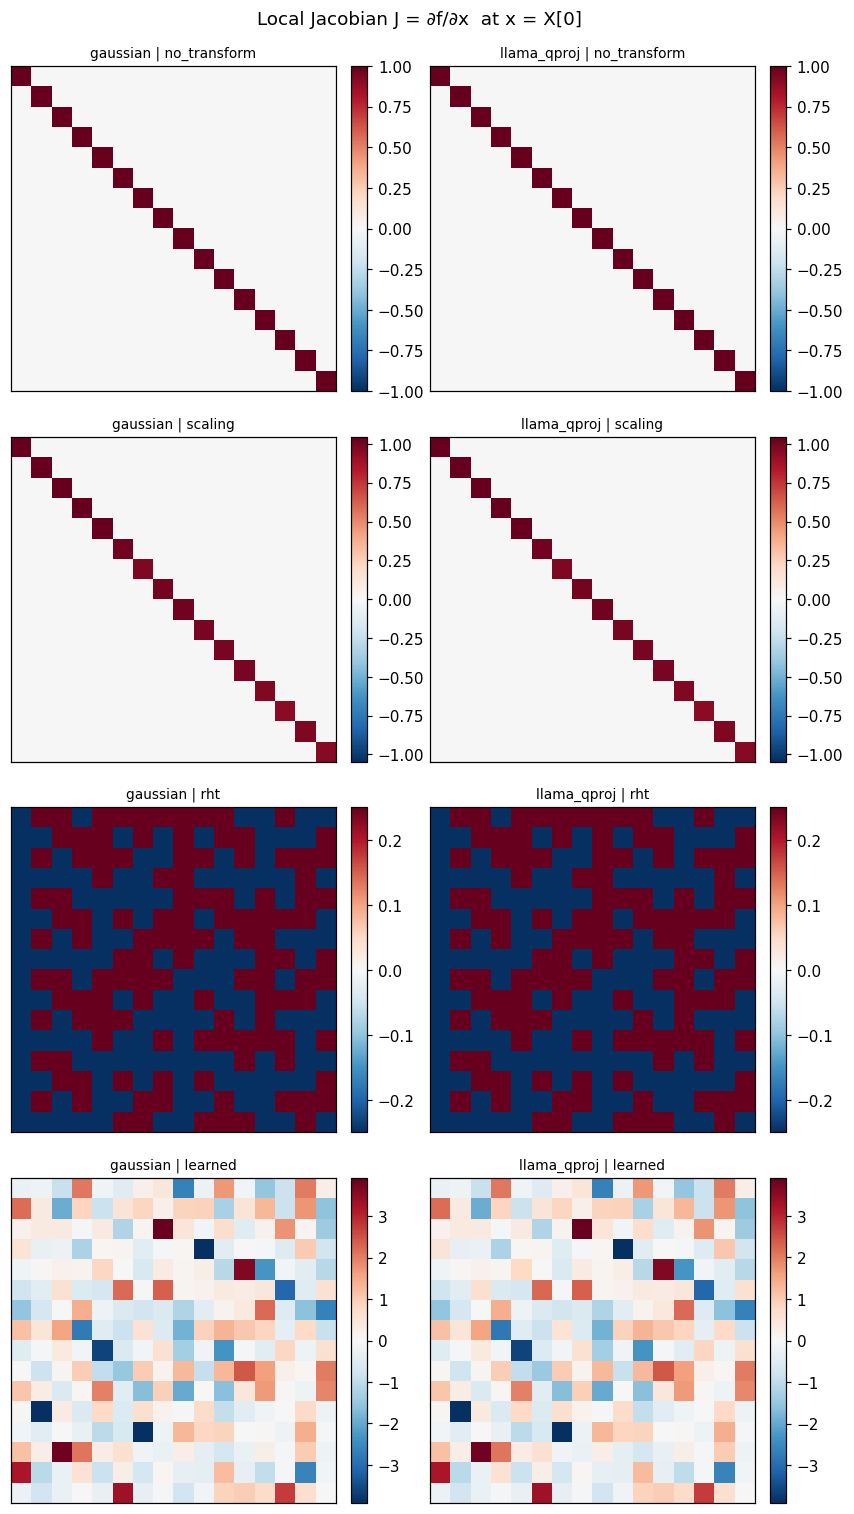

In [10]:
# 5a. J heatmap
fig, axes = plt.subplots(n_rows, n_cols, figsize=(4*n_cols, 3.5*n_rows), dpi=110)
if n_rows == 1: axes = axes[None, :]
for r, tname in enumerate(names_order):
    for c, ds in enumerate(datasets):
        J = JACOBIANS[(ds, tname)]
        ax = axes[r, c]
        vmax = float(J.abs().quantile(0.99))
        im = ax.imshow(J.numpy(), cmap='RdBu_r', vmin=-vmax, vmax=vmax)
        ax.set_title(f'{ds} | {tname}', fontsize=9)
        ax.set_xticks([]); ax.set_yticks([])
        plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
fig.suptitle('Local Jacobian J = ∂f/∂x  at x = X[0]', fontsize=12)
fig.tight_layout(rect=[0, 0, 1, 0.99])
fig.savefig(FIG_DIR / 'fig5a_jacobian_heatmap.png'); plt.show()


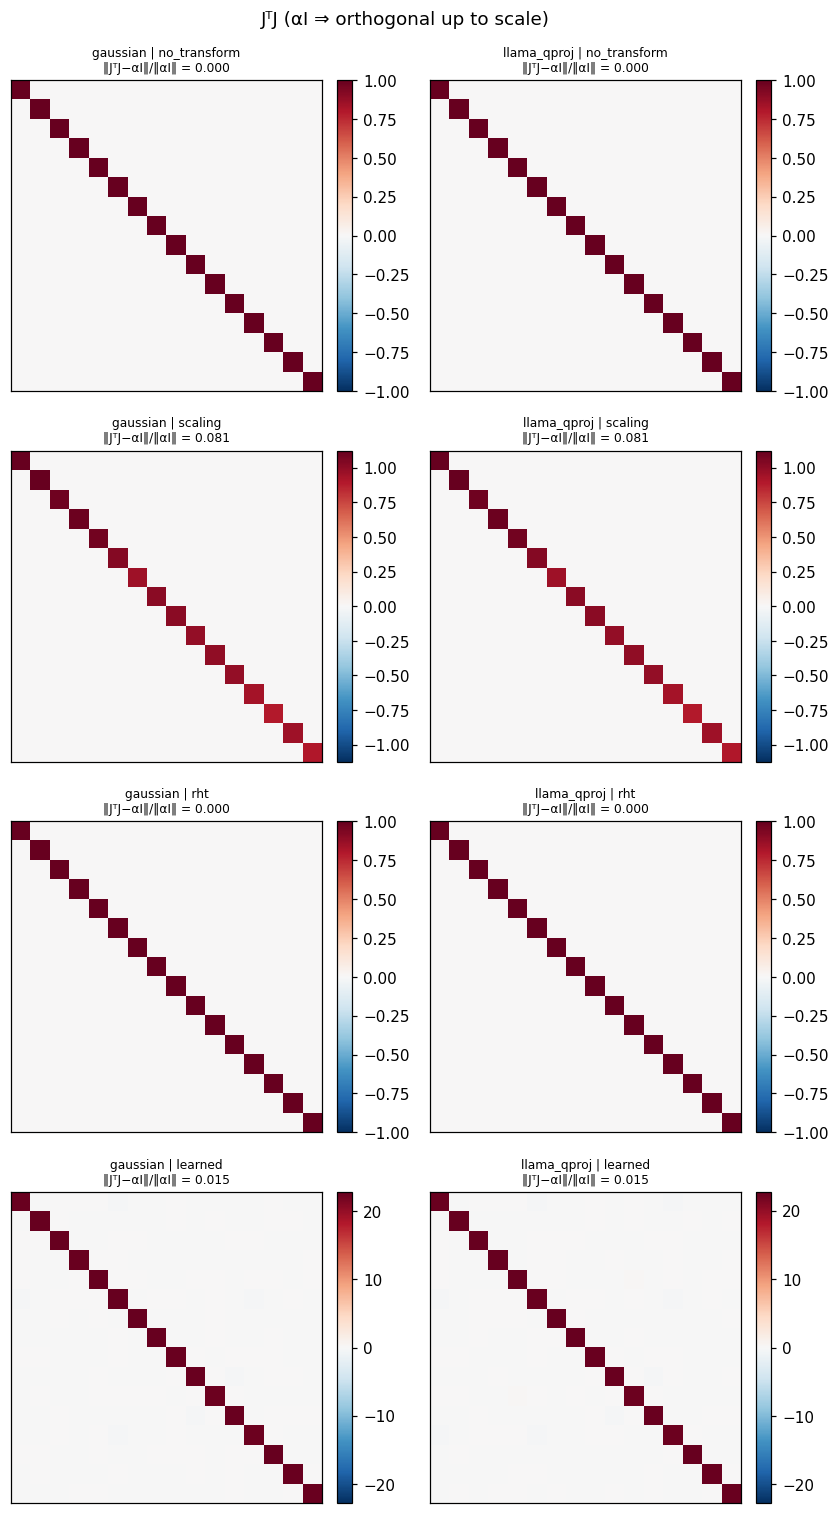

In [11]:
# 5b. JᵀJ — orthogonality
fig, axes = plt.subplots(n_rows, n_cols, figsize=(4*n_cols, 3.5*n_rows), dpi=110)
if n_rows == 1: axes = axes[None, :]
for r, tname in enumerate(names_order):
    for c, ds in enumerate(datasets):
        J = JACOBIANS[(ds, tname)]; G = J.T @ J
        ax = axes[r, c]
        vmax = float(G.abs().quantile(0.995))
        im = ax.imshow(G.numpy(), cmap='RdBu_r', vmin=-vmax, vmax=vmax)
        rel = RESULTS[(ds, tname)]['orthogonality']['frob_diff_rel']
        ax.set_title(f'{ds} | {tname}\n‖JᵀJ−αI‖/‖αI‖ = {rel:.3f}', fontsize=8)
        ax.set_xticks([]); ax.set_yticks([])
        plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
fig.suptitle('JᵀJ (αI ⇒ orthogonal up to scale)', fontsize=12)
fig.tight_layout(rect=[0, 0, 1, 0.99])
fig.savefig(FIG_DIR / 'fig5b_JtJ.png'); plt.show()


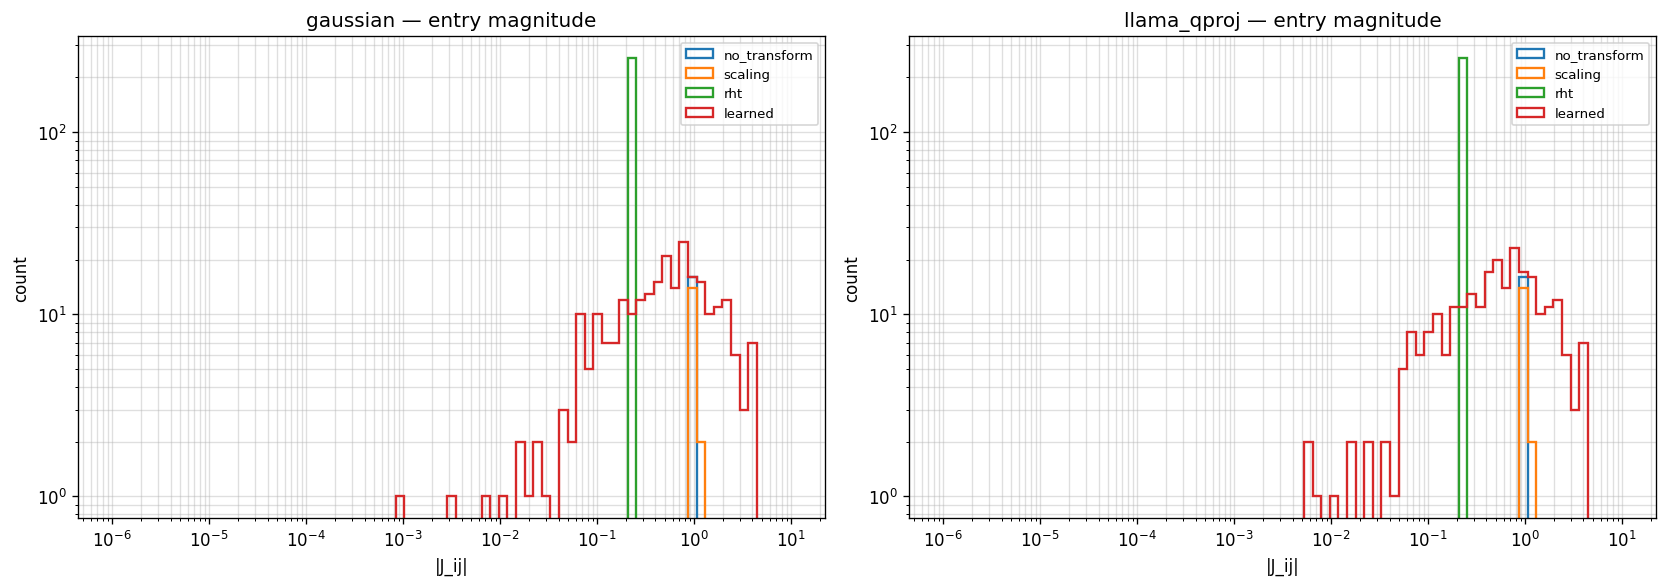

In [12]:
# 5c. Entry magnitude distribution (log-log)
fig, axes = plt.subplots(1, n_cols, figsize=(7*n_cols, 5), dpi=120)
if n_cols == 1: axes = [axes]
bins = np.logspace(-6, 1, 80)
for c, ds in enumerate(datasets):
    ax = axes[c]
    for tname in names_order:
        A = RESULTS[(ds, tname)]['entries']['A_flat']
        Ap = A[A > 1e-12]
        ax.hist(Ap, bins=bins, histtype='step', linewidth=1.4, label=tname)
    ax.set_xscale('log'); ax.set_yscale('log')
    ax.set_xlabel('|J_ij|'); ax.set_ylabel('count')
    ax.set_title(f'{ds} — entry magnitude'); ax.grid(True, which='both', alpha=0.4); ax.legend(fontsize=8)
fig.tight_layout(); fig.savefig(FIG_DIR / 'fig5c_entries.png'); plt.show()


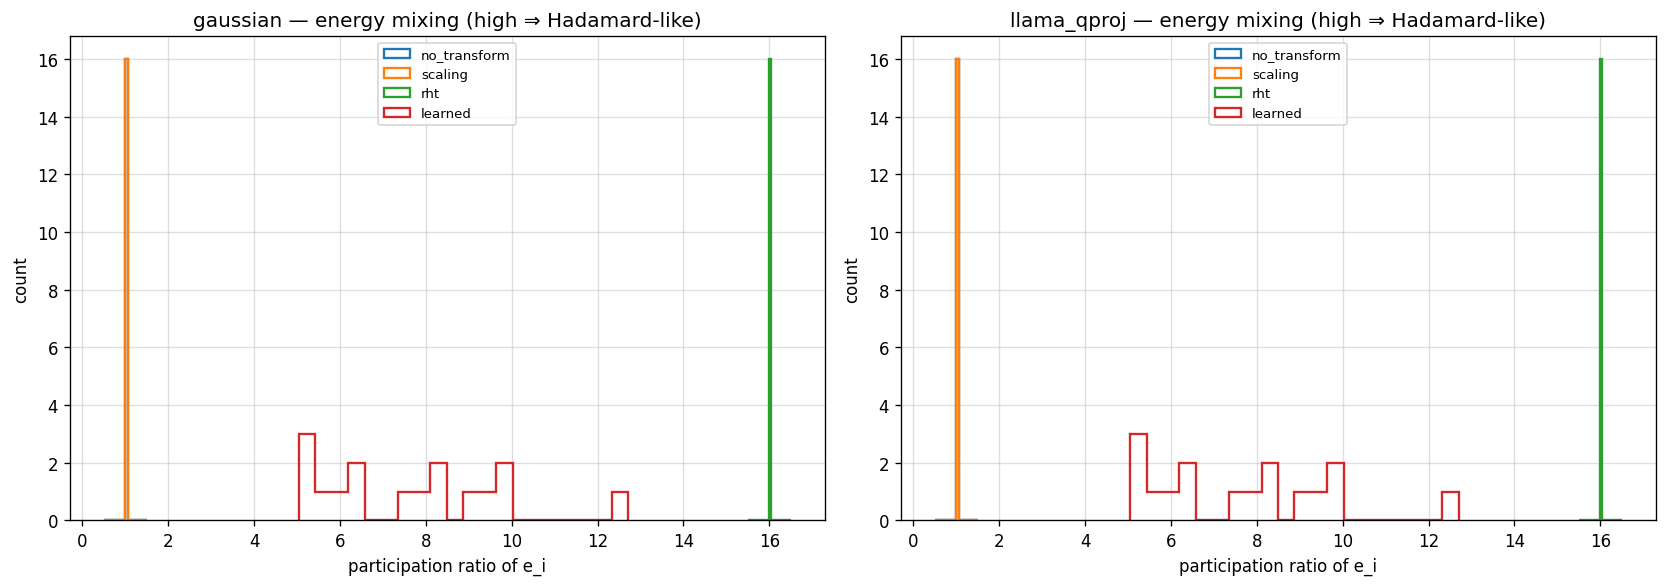

In [13]:
# 5d. Energy mixing — participation ratio
fig, axes = plt.subplots(1, n_cols, figsize=(7*n_cols, 5), dpi=120)
if n_cols == 1: axes = [axes]
for c, ds in enumerate(datasets):
    ax = axes[c]
    for tname in names_order:
        pr = RESULTS[(ds, tname)]['energy']['pr_per_col']
        ax.hist(pr, bins=20, histtype='step', linewidth=1.4, label=tname)
    ax.set_xlabel('participation ratio of e_i'); ax.set_ylabel('count')
    ax.set_title(f'{ds} — energy mixing (high ⇒ Hadamard-like)')
    ax.grid(True, alpha=0.4); ax.legend(fontsize=8)
fig.tight_layout(); fig.savefig(FIG_DIR / 'fig5d_energy.png'); plt.show()


In [14]:
# 5e. Summary table
import pandas as pd
rows = []
for (ds, tname), m in RESULTS.items():
    rows.append({'dataset': ds, 'transform': tname,
                 'ortho_rel': m['orthogonality']['frob_diff_rel'],
                 'm2m_median': m['entries']['max_to_mean_median'],
                 'participation_median': m['energy']['participation_median'],
                 'cond_pre':  m['covariance']['pre']['cond'],
                 'cond_post': m['covariance']['post']['cond'],
                 'diag_dom_post': m['covariance']['post']['diag_dom']})
df = pd.DataFrame(rows).sort_values(['dataset', 'transform']).reset_index(drop=True)
df.to_csv(FIG_DIR / 'summary_metrics.csv', index=False)
df


,dataset,transform,ortho_rel,m2m_median,participation_median,cond_pre,cond_post,diag_dom_post
0,gaussian,learned,0.014894,3.969304,7.575772,1.194236,1.198610,0.147590
1,gaussian,no_transform,0.000000,16.000000,1.000000,1.194236,1.194236,0.148774
2,gaussian,rht,0.000000,1.000000,16.000000,1.194236,1.194236,0.141212
3,gaussian,scaling,0.081298,16.000000,1.000000,1.194236,1.403495,0.148951
4,llama_qproj,learned,0.015026,3.965926,7.575771,1.428599,1.434017,0.246293
5,llama_qproj,no_transform,0.000000,16.000000,1.000000,1.428599,1.428599,0.174368
6,llama_qproj,rht,0.000000,1.000000,16.000000,1.428599,1.428599,0.284104
7,llama_qproj,scaling,0.081298,16.000000,1.000000,1.428599,1.244940,0.175852


## 6. Direct latent comparison
Cache `z = f(X)` for every (dataset, transform) — used by §7–§9.

In [15]:
LATENTS = {}
for ds_name, X in DATASETS.items():
    for tname, tf in TRANSFORMS.items():
        with torch.no_grad():
            z = tf(X).detach().cpu()
        LATENTS[(ds_name, tname)] = z
        print(f'{ds_name:12s} | {tname:14s}  shape={tuple(z.shape)}  mean={float(z.mean()):+.3f}  std={float(z.std()):.3f}')


gaussian     | no_transform    shape=(8192, 16)  mean=+0.000  std=0.999
gaussian     | scaling         shape=(8192, 16)  mean=+0.000  std=1.007
gaussian     | rht             shape=(8192, 16)  mean=-0.000  std=0.999
gaussian     | learned         shape=(8192, 16)  mean=+0.121  std=5.830
llama_qproj  | no_transform    shape=(8192, 16)  mean=+0.001  std=0.995
llama_qproj  | scaling         shape=(8192, 16)  mean=+0.001  std=1.000
llama_qproj  | rht             shape=(8192, 16)  mean=+0.003  std=0.995
llama_qproj  | learned         shape=(8192, 16)  mean=+0.107  std=5.824


## 7. Variance spectrum (Figure 1)

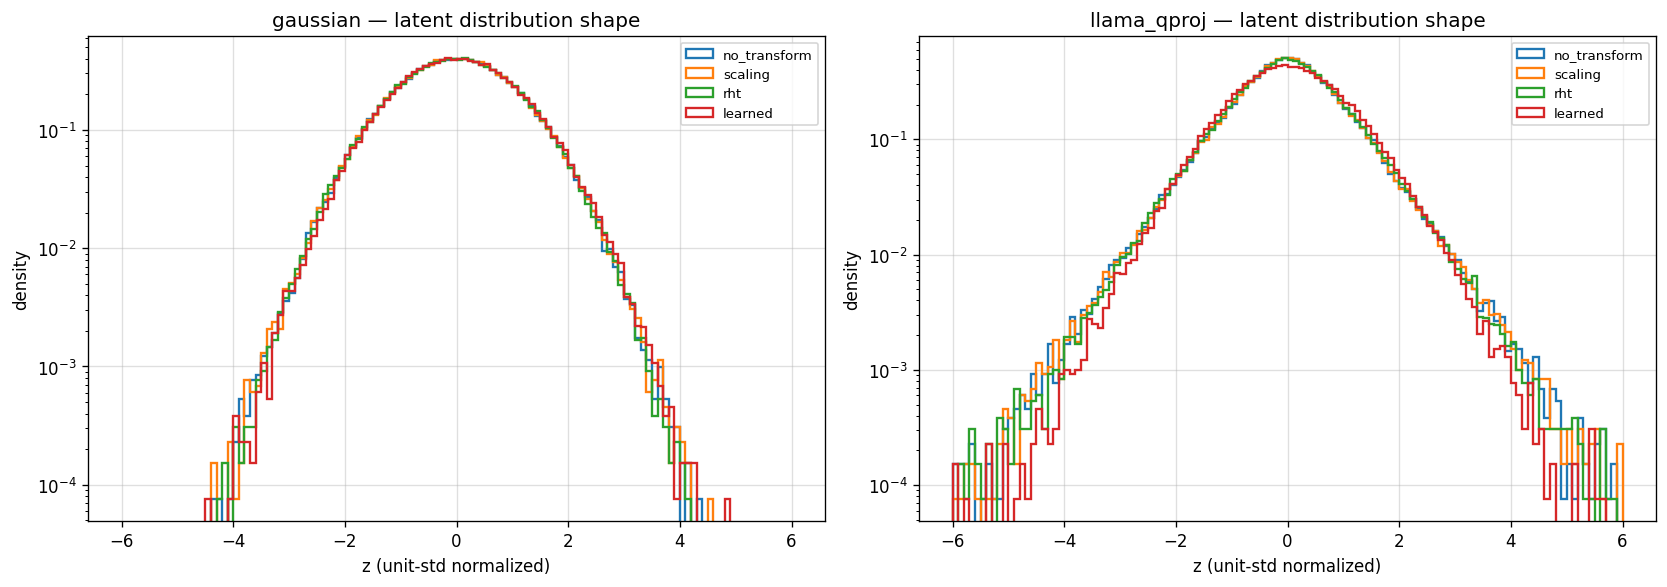

In [16]:
# 7a. Latent value distribution (per-tensor unit-std normalized → shape comparison)
fig, axes = plt.subplots(1, n_cols, figsize=(7*n_cols, 5), dpi=120)
if n_cols == 1: axes = [axes]
bins = np.linspace(-6, 6, 121)
for c, ds in enumerate(datasets):
    ax = axes[c]
    for tname in names_order:
        z = LATENTS[(ds, tname)].flatten().numpy()
        z = z / (z.std() + 1e-12)
        ax.hist(z, bins=bins, histtype='step', density=True, linewidth=1.4, label=tname)
    ax.set_yscale('log'); ax.set_xlabel('z (unit-std normalized)'); ax.set_ylabel('density')
    ax.set_title(f'{ds} — latent distribution shape')
    ax.grid(True, alpha=0.4); ax.legend(fontsize=8)
fig.tight_layout(); fig.savefig(FIG_DIR / 'fig7a_value_hist.png'); plt.show()


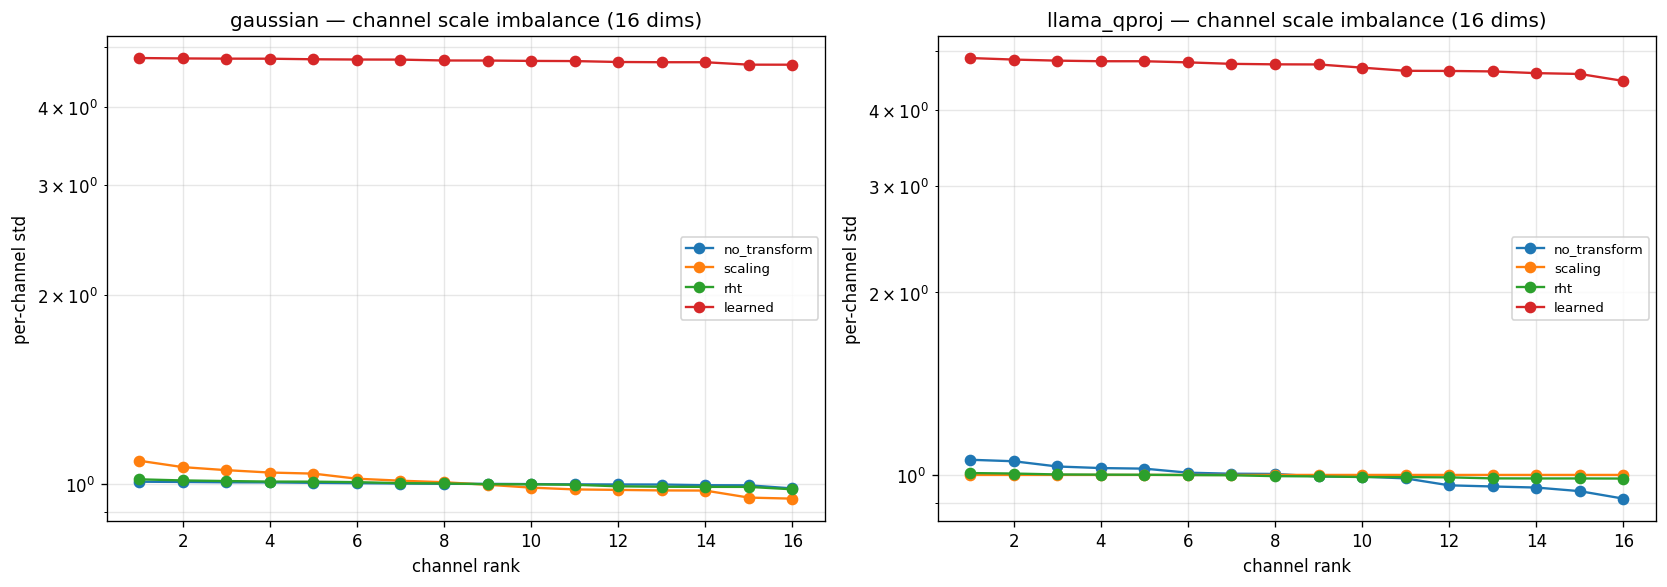

In [17]:
# 7b. Sorted per-channel std (16 channels)
fig, axes = plt.subplots(1, n_cols, figsize=(7*n_cols, 5), dpi=120)
if n_cols == 1: axes = [axes]
for c, ds in enumerate(datasets):
    ax = axes[c]
    for tname in names_order:
        z = LATENTS[(ds, tname)].numpy()
        sigma_sorted = np.sort(z.std(axis=0))[::-1]
        ax.plot(np.arange(1, len(sigma_sorted)+1), sigma_sorted,
                marker='o', linewidth=1.4, label=tname)
    ax.set_yscale('log'); ax.set_xlabel('channel rank'); ax.set_ylabel('per-channel std')
    ax.set_title(f'{ds} — channel scale imbalance (16 dims)')
    ax.grid(True, which='both', alpha=0.3); ax.legend(fontsize=8)
fig.tight_layout(); fig.savefig(FIG_DIR / 'fig7b_sorted_std.png'); plt.show()


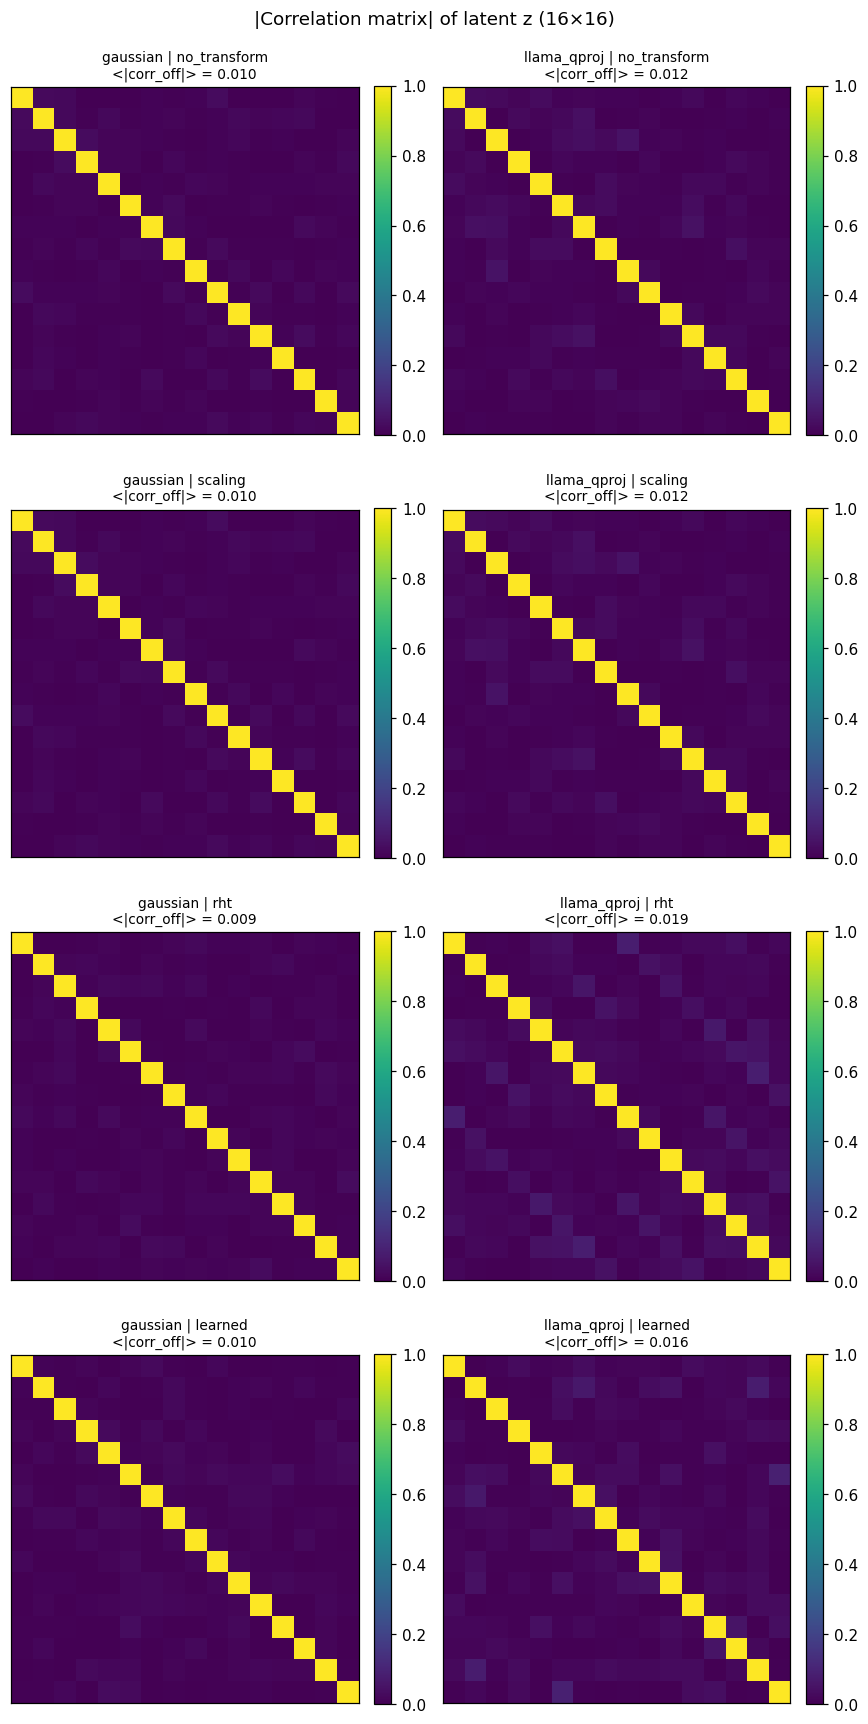

In [18]:
# 7c. |Correlation| heatmap — full 16×16 (no truncation needed)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(4*n_cols, 4*n_rows), dpi=110)
if n_rows == 1: axes = axes[None, :]
for r, tname in enumerate(names_order):
    for c, ds in enumerate(datasets):
        z = LATENTS[(ds, tname)].numpy()
        zc = z - z.mean(axis=0, keepdims=True)
        zn = zc / (zc.std(axis=0, keepdims=True) + 1e-12)
        D = zn.shape[1]
        corr = (zn.T @ zn) / zn.shape[0]
        off = corr - np.diag(np.diag(corr))
        off_mean = float(np.abs(off).sum() / (D*D - D))
        ax = axes[r, c]
        im = ax.imshow(np.abs(corr), cmap='viridis', vmin=0, vmax=1)
        ax.set_title(f'{ds} | {tname}\n<|corr_off|> = {off_mean:.3f}', fontsize=9)
        ax.set_xticks([]); ax.set_yticks([])
        plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
fig.suptitle('|Correlation matrix| of latent z (16×16)', fontsize=12)
fig.tight_layout(rect=[0, 0, 1, 0.99])
fig.savefig(FIG_DIR / 'fig7c_corr.png'); plt.show()


## 8. Cumulative energy (Figure 2)
For each transform, plot the cumulative fraction of total variance captured by the top-k channels (sorted descending).
- Diagonal (linear) curve ⇒ energy spread uniformly (Hadamard-like).
- Strongly bowed curve ⇒ a few channels carry most of the energy (compaction).

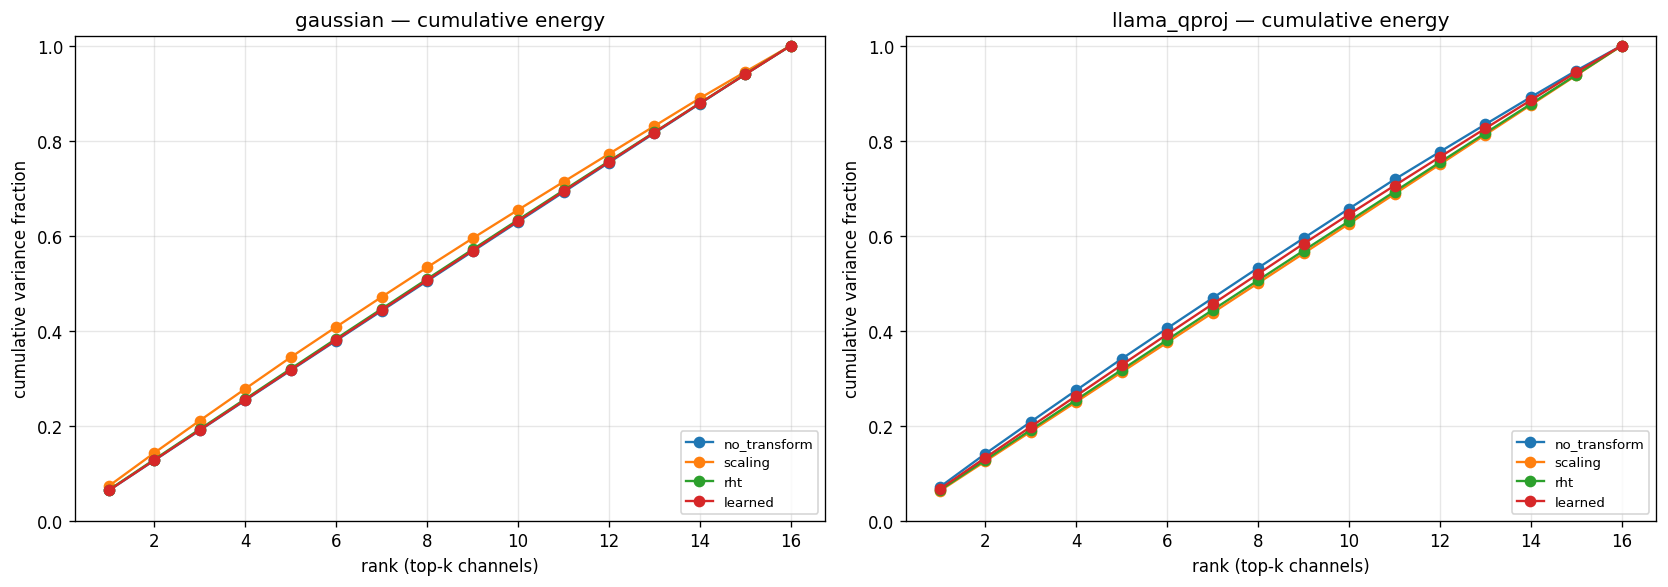

In [19]:
# 8. Cumulative energy curve (single panel)
fig, axes = plt.subplots(1, n_cols, figsize=(7*n_cols, 5), dpi=120)
if n_cols == 1: axes = [axes]
for c, ds in enumerate(datasets):
    ax = axes[c]
    for tname in names_order:
        z = LATENTS[(ds, tname)].numpy()
        v = np.sort(z.var(axis=0))[::-1]
        cum = np.cumsum(v) / max(v.sum(), 1e-12)
        ax.plot(np.arange(1, len(v)+1), cum, marker='o', linewidth=1.4, label=tname)
    ax.set_xlabel('rank (top-k channels)')
    ax.set_ylabel('cumulative variance fraction')
    ax.set_title(f'{ds} — cumulative energy')
    ax.set_ylim(0, 1.02)
    ax.grid(True, alpha=0.3); ax.legend(fontsize=8, loc='lower right')
fig.tight_layout(); fig.savefig(FIG_DIR / 'fig8_cumulative_energy.png'); plt.show()


## 9. Quantization noise effect (Figure 3)
For each transform, build the inverse, sweep a per-channel uniform quantizer Δ_i = c·σ_i,
and report **input-space NMSE** ‖T⁻¹(Q(z)) − T⁻¹(z)‖² / ‖T⁻¹(z)‖².
This isolates *the extra distortion from quantization*, separate from the autoencoder's identity loss.

In [20]:
def make_identity_inverse():
    return (lambda z: z.clone())

def make_scaling_inverse(X_ref):
    std = X_ref.float().std(dim=0).clamp_min(1e-9).to(DEVICE)
    return (lambda z: z * std.unsqueeze(0))

def make_rht_inverse(dim=BLOCK_DIM, seed=0):
    g = torch.Generator().manual_seed(seed)
    diag = (torch.randint(0, 2, (dim,), generator=g).mul(2).sub(1)).float().to(DEVICE)
    H = hadamard_matrix(dim).to(DEVICE)        # symmetric, orthogonal
    return (lambda z: (z @ H) * diag.unsqueeze(0))

def make_learned_inverse(model, q_level=Q_LEVEL):
    dec = model.g_s
    def f(z):
        z_in = z.unsqueeze(0).contiguous()
        ql = torch.full((1, z.shape[0]), q_level, dtype=torch.long, device=z.device)
        q_embed = model._get_q_embed(q_input=ql, reference=z_in)
        x = dec(z_in, q_embed)
        return x.squeeze(0)
    return f

INVERSES = OrderedDict()
INVERSES['no_transform'] = make_identity_inverse()
INVERSES['scaling']      = make_scaling_inverse(X_LLAMA)
INVERSES['rht']          = make_rht_inverse(dim=BLOCK_DIM, seed=0)
INVERSES['learned']      = make_learned_inverse(nwc, q_level=Q_LEVEL)
print('Inverses built:', list(INVERSES.keys()))


Inverses built: ['no_transform', 'scaling', 'rht', 'learned']


gaussian     | no_transform    NMSE@c=1.0=8.360e-02  NMSE@c=0.1=3.578e-04
gaussian     | scaling         NMSE@c=1.0=8.360e-02  NMSE@c=0.1=3.578e-04
gaussian     | rht             NMSE@c=1.0=8.313e-02  NMSE@c=0.1=3.588e-04
gaussian     | learned         NMSE@c=1.0=8.322e-02  NMSE@c=0.1=3.612e-04
llama_qproj  | no_transform    NMSE@c=1.0=8.260e-02  NMSE@c=0.1=3.584e-04
llama_qproj  | scaling         NMSE@c=1.0=8.260e-02  NMSE@c=0.1=3.584e-04
llama_qproj  | rht             NMSE@c=1.0=8.267e-02  NMSE@c=0.1=3.595e-04
llama_qproj  | learned         NMSE@c=1.0=8.316e-02  NMSE@c=0.1=3.586e-04


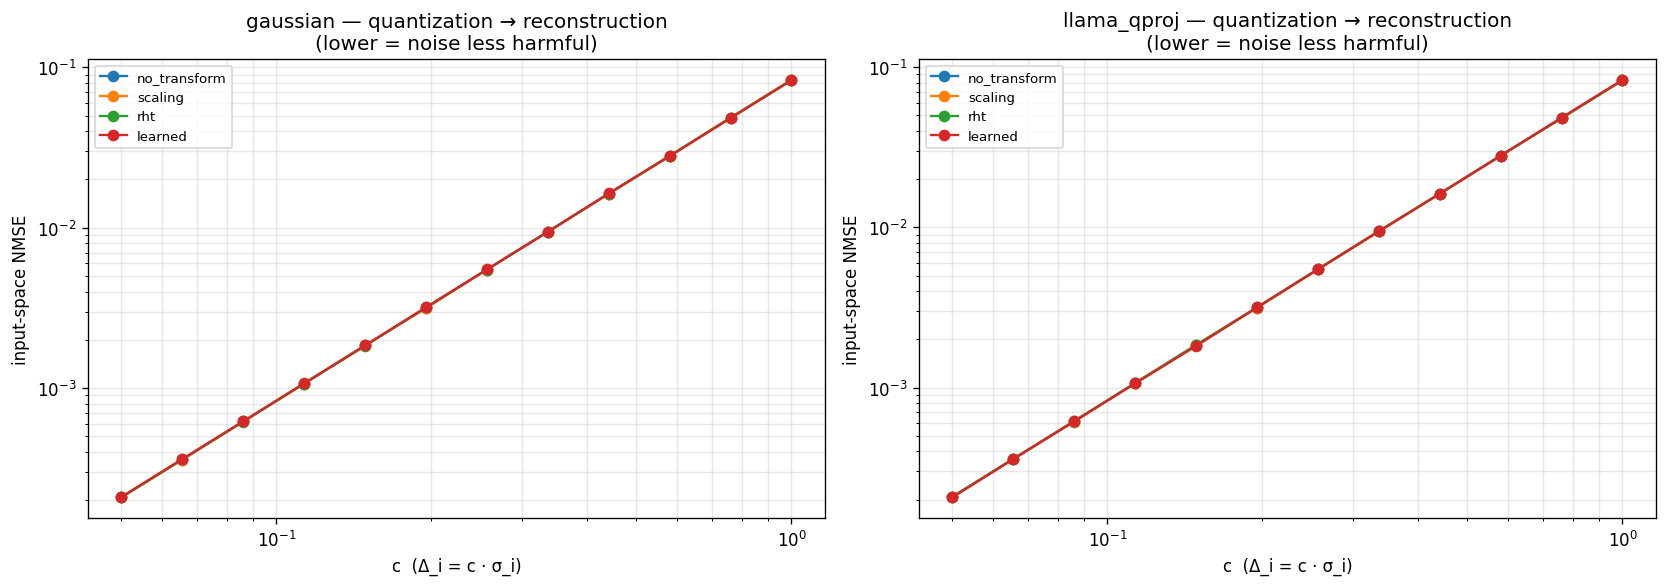

In [21]:
@torch.no_grad()
def rd_sweep(z, inv, cs):
    sigma = z.std(dim=0, keepdim=True).clamp_min(1e-9)
    x_ref = inv(z)
    denom = (x_ref ** 2).mean().clamp_min(1e-12)
    out = []
    for c in cs:
        Delta = c * sigma
        zq = torch.round(z / Delta) * Delta
        x_rec = inv(zq)
        nmse = ((x_rec - x_ref) ** 2).mean() / denom
        out.append(float(nmse.item()))
    return np.array(out)

CS = np.geomspace(0.05, 1.0, 12)
RD = {}
for ds_name, X in DATASETS.items():
    for tname, tf in TRANSFORMS.items():
        with torch.no_grad():
            z = tf(X)
        nmse = rd_sweep(z, INVERSES[tname], CS)
        RD[(ds_name, tname)] = nmse
        print(f'{ds_name:12s} | {tname:14s}  NMSE@c=1.0={nmse[-1]:.3e}  NMSE@c=0.1={nmse[1]:.3e}')

fig, axes = plt.subplots(1, n_cols, figsize=(7*n_cols, 5), dpi=120)
if n_cols == 1: axes = [axes]
for c_, ds in enumerate(datasets):
    ax = axes[c_]
    for tname in names_order:
        ax.plot(CS, RD[(ds, tname)], marker='o', linewidth=1.4, label=tname)
    ax.set_xscale('log'); ax.set_yscale('log')
    ax.set_xlabel('c  (Δ_i = c · σ_i)')
    ax.set_ylabel('input-space NMSE')
    ax.set_title(f'{ds} — quantization → reconstruction\n(lower = noise less harmful)')
    ax.grid(True, which='both', alpha=0.3); ax.legend(fontsize=8)
fig.tight_layout(); fig.savefig(FIG_DIR / 'fig9_quant_recon.png'); plt.show()


## 10. 2-D toy (Figure 4)
2-D anisotropic correlated Gaussian — visualize how each transform reshapes the cloud
relative to a uniform scalar quantization grid.  Caveat: the trained `g_a` is 16-dim,
so the **Whitening** panel is shown as a **learned-ideal** stand-in (not the actual learned encoder).

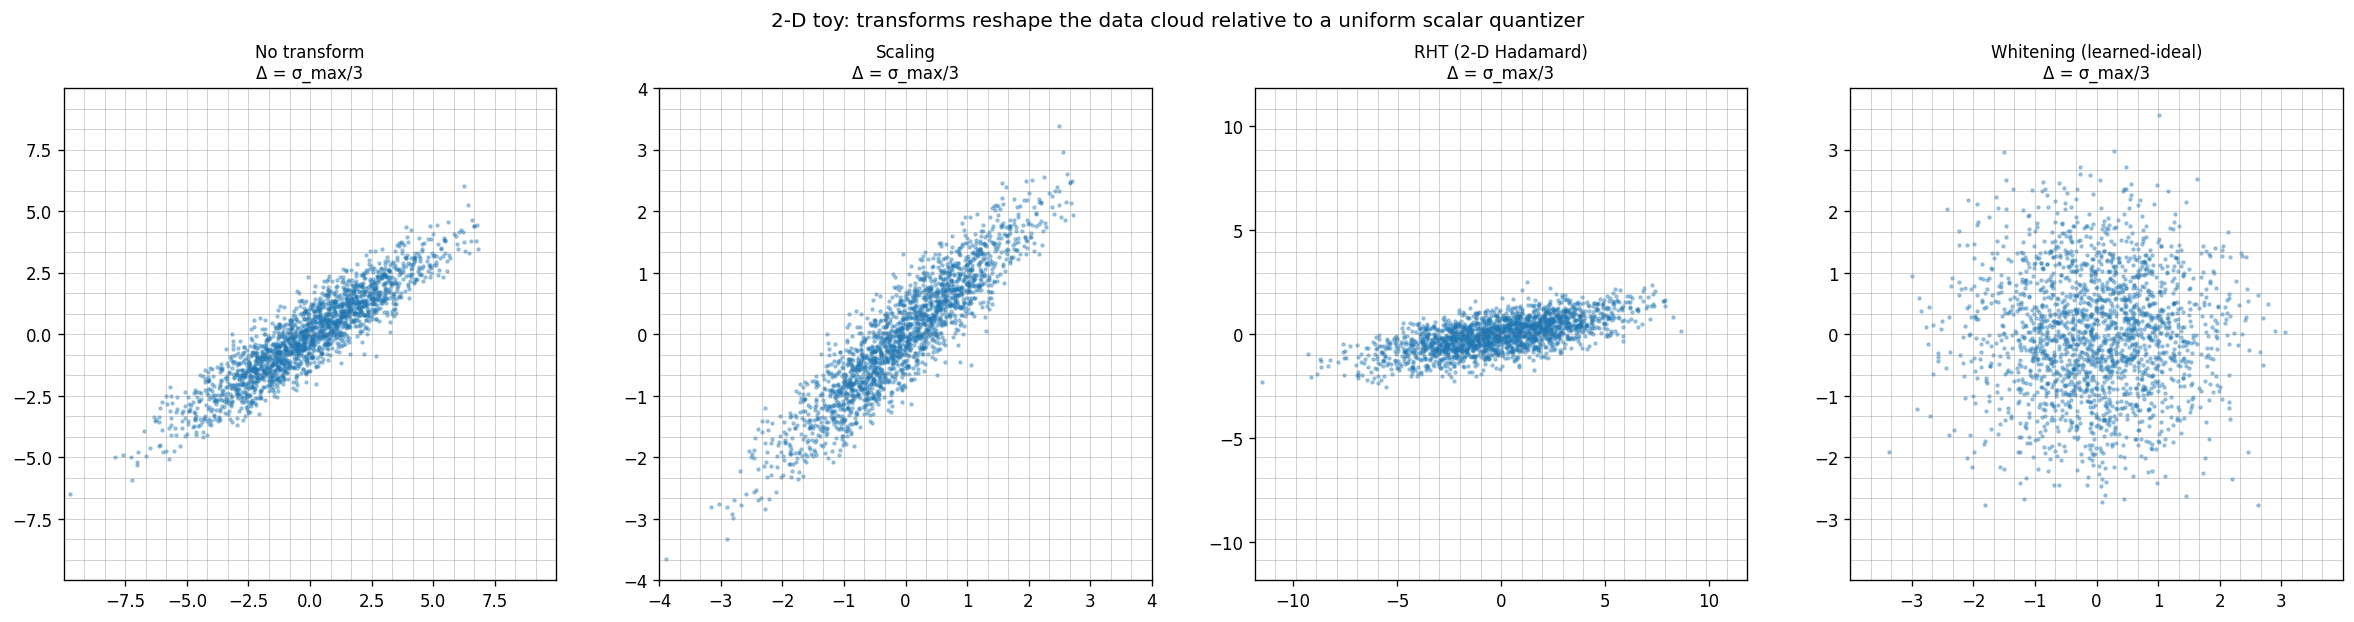

In [22]:
def quantize_grid_lines(ax, x_min, x_max, y_min, y_max, delta, color='gray', alpha=0.35):
    xs = np.arange(np.floor(x_min/delta)*delta, x_max + delta, delta)
    ys = np.arange(np.floor(y_min/delta)*delta, y_max + delta, delta)
    for x in xs: ax.axvline(x, color=color, alpha=alpha, linewidth=0.6)
    for y in ys: ax.axhline(y, color=color, alpha=alpha, linewidth=0.6)

# 2-D correlated Gaussian (anisotropic, tilted)
N2D = 2000
rng = np.random.default_rng(0)
theta = np.deg2rad(35.0)
R = np.array([[np.cos(theta), -np.sin(theta)], [np.sin(theta), np.cos(theta)]])
S = np.diag([3.0, 0.6])
X2 = rng.standard_normal((N2D, 2)) @ (R @ S).T

def t_identity(X): return X.copy()
def t_scaling(X):  return X / X.std(axis=0, keepdims=True)
def t_rht(X):
    H = np.array([[1.0, 1.0], [1.0, -1.0]]) / np.sqrt(2.0)
    g = np.random.default_rng(0)
    diag = g.choice([-1.0, 1.0], size=2)
    return (X * diag) @ H.T
def t_whitening(X):
    Xc = X - X.mean(axis=0, keepdims=True)
    cov = (Xc.T @ Xc) / (Xc.shape[0] - 1)
    eigvals, eigvecs = np.linalg.eigh(cov)
    W = eigvecs @ np.diag(1.0 / np.sqrt(np.clip(eigvals, 1e-12, None))) @ eigvecs.T
    return Xc @ W

panels = [('No transform',                t_identity),
          ('Scaling',                     t_scaling),
          ('RHT (2-D Hadamard)',          t_rht),
          ('Whitening (learned-ideal)',   t_whitening)]

fig, axes = plt.subplots(1, 4, figsize=(20, 5), dpi=120)
for ax, (name, fn) in zip(axes, panels):
    Y = fn(X2)
    span = float(Y.std(axis=0).max())
    delta = span / 3.0
    lim = 4.0 * span
    quantize_grid_lines(ax, -lim, lim, -lim, lim, delta)
    ax.scatter(Y[:, 0], Y[:, 1], s=3, alpha=0.35, color='C0')
    ax.set_xlim(-lim, lim); ax.set_ylim(-lim, lim); ax.set_aspect('equal')
    ax.set_title(f'{name}\nΔ = σ_max/3', fontsize=10); ax.grid(False)
fig.suptitle('2-D toy: transforms reshape the data cloud relative to a uniform scalar quantizer', fontsize=12)
fig.tight_layout(rect=[0, 0, 1, 0.97])
fig.savefig(FIG_DIR / 'fig10_2d_toy.png'); plt.show()


## 11. Empirical operational coding gain (Figure 5)

Operational rate-distortion under a uniform scalar quantizer per-channel, with rate measured by the
**factorized empirical entropy** of the quantized symbols (i.e., **no learned entropy model**).
This isolates the role of the *transform* itself — does it produce a representation that
is inherently easier to quantize and entropy-code?

For each transform $T$:
1. $z = T(x)$, per-channel scalar quantize $\hat z_i = \mathrm{round}(z_i / (c\,\sigma_i))\cdot c\,\sigma_i$
2. $\hat x = T^{-1}(\hat z)$ (or $g_\psi$ for the learned transform)
3. $D_T(c) = \frac{1}{Nd}\sum_n \lVert x^{(n)}-\hat x^{(n)}\rVert^2$
4. $R_T(c) = \frac{1}{d}\sum_i H_\text{emp}(\hat z_{\Delta_i,i})$  &nbsp;[bits/element]

We sweep a single scalar $c$ (relative quantization granularity) and use **per-channel**
$\Delta_i = c\cdot\sigma_i$.  This puts every transform on the same rate budget per dim and
avoids scale-mismatch bias that arises with a single scalar $\Delta$ across dims with very
different variances.

Coding gain at target rate $R^\*$:
$G_T^\text{dB}(R^\*) = 10\log_{10}\!\bigl(D_\text{id}(R^\*)/D_T(R^\*)\bigr)$

We additionally report the **learned entropy rate** $R^\text{learned} = \mathbb E[-\log_2 p_\theta(\hat z)]$
(via the trained entropy bottleneck, $\Delta{=}1$ rounding) for the learned transform, so
the gap between $R^\text{emp}$ and $R^\text{learned}$ shows how much extra rate reduction
comes from the *learned entropy model* on top of the transform.

In [23]:
# 11a. Empirical entropy + RD-point sweep (per-channel Δ_i = c·σ_i)
@torch.no_grad()
def empirical_entropy_per_dim(z_idx: torch.Tensor) -> float:
    """z_idx: (N, d) integer tensor.  Returns (1/d)·Σᵢ H_emp(z_idx[:,i])  [bits/element]."""
    N, d = z_idx.shape
    z_idx = z_idx.cpu()
    total = 0.0
    for i in range(d):
        _, counts = torch.unique(z_idx[:, i], return_counts=True)
        p = counts.float() / N
        total += -(p * torch.log2(p.clamp_min(1e-12))).sum().item()
    return total / d

@torch.no_grad()
def rd_point_perchannel(x_ref, z, inv, c):
    """Per-channel uniform scalar quantizer with Δ_i = c·σ_i.  Returns (R [bits/el], D)."""
    sigma = z.std(dim=0, keepdim=True).clamp_min(1e-12)        # (1, d)
    Delta = c * sigma                                          # (1, d)
    z_idx = torch.round(z / Delta).long()
    z_hat = z_idx.float() * Delta
    x_hat = inv(z_hat)
    D = ((x_ref - x_hat) ** 2).mean().item()                   # per-element MSE in input space
    R = empirical_entropy_per_dim(z_idx)                       # bits/element
    return R, D

CS_RD = np.geomspace(0.01, 4.0, 24)                            # quantization granularity in σ-units
RD_CURVES = {}
for ds_name, X in DATASETS.items():
    for tname, tf in TRANSFORMS.items():
        with torch.no_grad():
            z = tf(X)
        Rs, Ds = [], []
        for c_ in CS_RD:
            R, D = rd_point_perchannel(X, z, INVERSES[tname], float(c_))
            Rs.append(R); Ds.append(D)
        RD_CURVES[(ds_name, tname)] = (np.array(Rs), np.array(Ds))
        print(f'{ds_name:12s} | {tname:14s}  R∈[{min(Rs):.2f},{max(Rs):.2f}]  D∈[{min(Ds):.2e},{max(Ds):.2e}]')


gaussian     | no_transform    R∈[0.31,8.63]  D∈[8.31e-06,8.61e-01]
gaussian     | scaling         R∈[0.31,8.63]  D∈[8.31e-06,8.61e-01]


gaussian     | rht             R∈[0.31,8.63]  D∈[8.35e-06,8.63e-01]


gaussian     | learned         R∈[0.46,8.63]  D∈[9.71e-05,1.14e+00]
llama_qproj  | no_transform    R∈[0.36,8.51]  D∈[8.27e-06,7.18e-01]


llama_qproj  | scaling         R∈[0.36,8.51]  D∈[8.27e-06,7.18e-01]
llama_qproj  | rht             R∈[0.36,8.58]  D∈[8.22e-06,7.38e-01]


llama_qproj  | learned         R∈[0.48,8.58]  D∈[1.00e-04,1.12e+00]


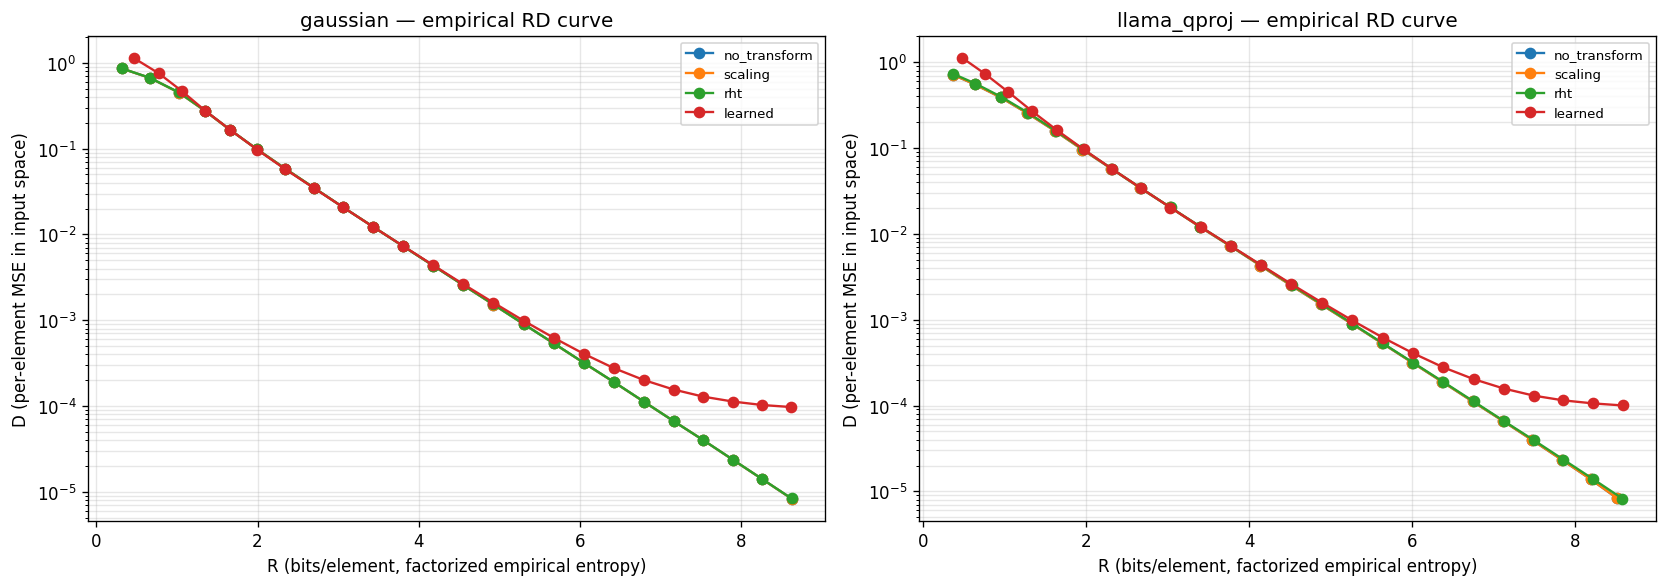

In [24]:
# 11b. Plot empirical RD curves (R = factorized empirical entropy, D = per-element MSE)
fig, axes = plt.subplots(1, n_cols, figsize=(7*n_cols, 5), dpi=120)
if n_cols == 1: axes = [axes]
for c, ds in enumerate(datasets):
    ax = axes[c]
    for tname in names_order:
        R, D = RD_CURVES[(ds, tname)]
        s = np.argsort(R)
        ax.plot(R[s], D[s], marker='o', linewidth=1.4, label=tname)
    ax.set_yscale('log')
    ax.set_xlabel('R (bits/element, factorized empirical entropy)')
    ax.set_ylabel('D (per-element MSE in input space)')
    ax.set_title(f'{ds} — empirical RD curve')
    ax.grid(True, which='both', alpha=0.3); ax.legend(fontsize=8)
fig.tight_layout(); fig.savefig(FIG_DIR / 'fig11_rd_curves.png'); plt.show()


In [25]:
# 11c. Coding gain G_T^dB(R*) at target rates (interpolated on log-D)
TARGET_RATES = [1.0, 2.0, 3.0, 4.0, 5.0]
rows = []
for ds in datasets:
    R_id, D_id = RD_CURVES[(ds, 'no_transform')]
    s_id = np.argsort(R_id)
    R_id_s = R_id[s_id]; logD_id_s = np.log10(D_id[s_id])
    for tname in names_order:
        R, D = RD_CURVES[(ds, tname)]
        s = np.argsort(R)
        row = {'dataset': ds, 'transform': tname}
        for r_star in TARGET_RATES:
            log_did = np.interp(r_star, R_id_s, logD_id_s)
            log_dt  = np.interp(r_star, R[s], np.log10(D[s]))
            row[f'G_dB@R={r_star:.0f}'] = 10.0 * (log_did - log_dt)
        rows.append(row)
df_gain = pd.DataFrame(rows)
df_gain.to_csv(FIG_DIR / 'fig11_coding_gain_table.csv', index=False)
print('Empirical coding gain G_T^dB at target rates (R* in bits/element):')
df_gain


Empirical coding gain G_T^dB at target rates (R* in bits/element):


,dataset,transform,G_dB@R=1,G_dB@R=2,G_dB@R=3,G_dB@R=4,G_dB@R=5
0,gaussian,no_transform,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
1,gaussian,scaling,0.000000e+00,0.000000e+00,0.000000e+00,-1.345882e-07,2.686536e-07
2,gaussian,rht,-1.419056e-02,1.916231e-02,-5.602639e-03,1.543557e-03,-1.625780e-02
3,gaussian,learned,-4.991183e-01,5.009805e-02,1.163334e-03,-3.484513e-02,-2.550230e-01
4,llama_qproj,no_transform,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
5,llama_qproj,scaling,5.631867e-07,3.884662e-08,3.680500e-07,0.000000e+00,2.272688e-07
6,llama_qproj,rht,-1.027622e-01,-7.671239e-02,-1.572477e-02,-5.323310e-02,-7.369782e-02
7,llama_qproj,learned,-1.233639e+00,-1.045265e-01,7.756553e-04,-9.212433e-02,-3.153436e-01


gaussian      learned-EB:  R^learned=4.384,  R^emp(Δ=1)=4.293  (EB saves -0.091 bits/el),  D=3.751e-03
llama_qproj   learned-EB:  R^learned=4.283,  R^emp(Δ=1)=4.248  (EB saves -0.035 bits/el),  D=3.742e-03


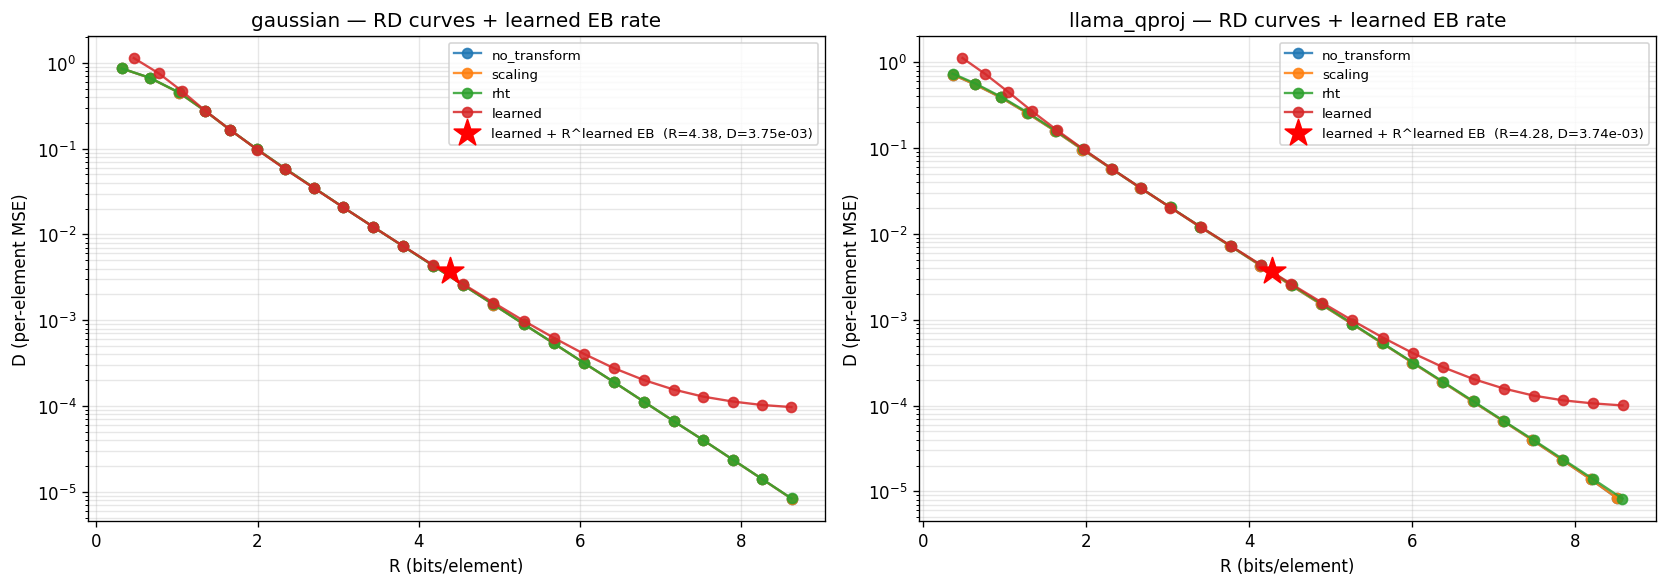

In [26]:
# 11d. Learned entropy-model rate point  (R^learned via trained EntropyBottleneck, Δ=1)
@torch.no_grad()
def learned_eb_rate(model, z, q_level=Q_LEVEL):
    """z: (N, M).  Returns (R^learned [bits/element], x_hat).
       Uses model.entropy_bottleneck (eval-mode rounding to nearest int) +
       model.g_s for reconstruction with q_embed."""
    # EB expects (B, C, *) with channels at dim 1
    z_perm = z.unsqueeze(0).permute(0, 2, 1).contiguous()           # (1, M, N)
    z_hat_perm, likelihoods = model.entropy_bottleneck(z_perm)
    z_hat = z_hat_perm.permute(0, 2, 1).squeeze(0)                  # (N, M)
    bits_per_el = -torch.log2(likelihoods.clamp_min(1e-12)).mean().item()
    # Decode through g_s with q_embed
    z_hat_in = z_hat.unsqueeze(0).contiguous()
    ql = torch.full((1, z_hat.shape[0]), q_level, dtype=torch.long, device=z_hat.device)
    q_embed = model._get_q_embed(q_input=ql, reference=z_hat_in)
    x_hat = model.g_s(z_hat_in, q_embed).squeeze(0)
    return bits_per_el, x_hat

LEARNED_PTS = {}
for ds_name, X in DATASETS.items():
    with torch.no_grad():
        z = TRANSFORMS['learned'](X)
        R_l, x_hat = learned_eb_rate(nwc, z)
        D_l = ((X - x_hat) ** 2).mean().item()
    LEARNED_PTS[ds_name] = (R_l, D_l)
    # Compare to empirical at Δ=1 for the same transform
    z_idx_1 = torch.round(z).long()
    R_emp_1 = empirical_entropy_per_dim(z_idx_1)
    print(f'{ds_name:12s}  learned-EB:  R^learned={R_l:.3f},  R^emp(Δ=1)={R_emp_1:.3f}  '
          f'(EB saves {R_emp_1 - R_l:+.3f} bits/el),  D={D_l:.3e}')

# Overlay R^learned point on the empirical RD plot
fig, axes = plt.subplots(1, n_cols, figsize=(7*n_cols, 5), dpi=120)
if n_cols == 1: axes = [axes]
for c, ds in enumerate(datasets):
    ax = axes[c]
    for tname in names_order:
        R, D = RD_CURVES[(ds, tname)]
        s = np.argsort(R)
        ax.plot(R[s], D[s], marker='o', linewidth=1.4, label=f'{tname}', alpha=0.85)
    R_l, D_l = LEARNED_PTS[ds]
    ax.scatter([R_l], [D_l], marker='*', s=280, color='red', zorder=5,
               label=f'learned + R^learned EB  (R={R_l:.2f}, D={D_l:.2e})')
    ax.set_yscale('log')
    ax.set_xlabel('R (bits/element)')
    ax.set_ylabel('D (per-element MSE)')
    ax.set_title(f'{ds} — RD curves + learned EB rate')
    ax.grid(True, which='both', alpha=0.3); ax.legend(fontsize=8)
fig.tight_layout(); fig.savefig(FIG_DIR / 'fig11_rd_with_learned_rate.png'); plt.show()


## 12. Per-entry channel mixing (Figure 6)

For a transform $z = T(x)$, **column $i$ of the Jacobian** $J = \partial z/\partial x$ tells us
how a single input entry distributes across the 16 output channels:
$$J[:, i] = (\partial z_0/\partial x_i,\ \partial z_1/\partial x_i,\ \dots,\ \partial z_{15}/\partial x_i).$$

Reference patterns (column $i$):
- **identity**: $e_i$ — single spike of magnitude 1 at output channel $i$
- **RHT**: 16 entries of magnitude $1/\sqrt{16} \approx 0.25$, signs randomized → uniform mixing
- **learned**: shows the *actually learned* mixing pattern

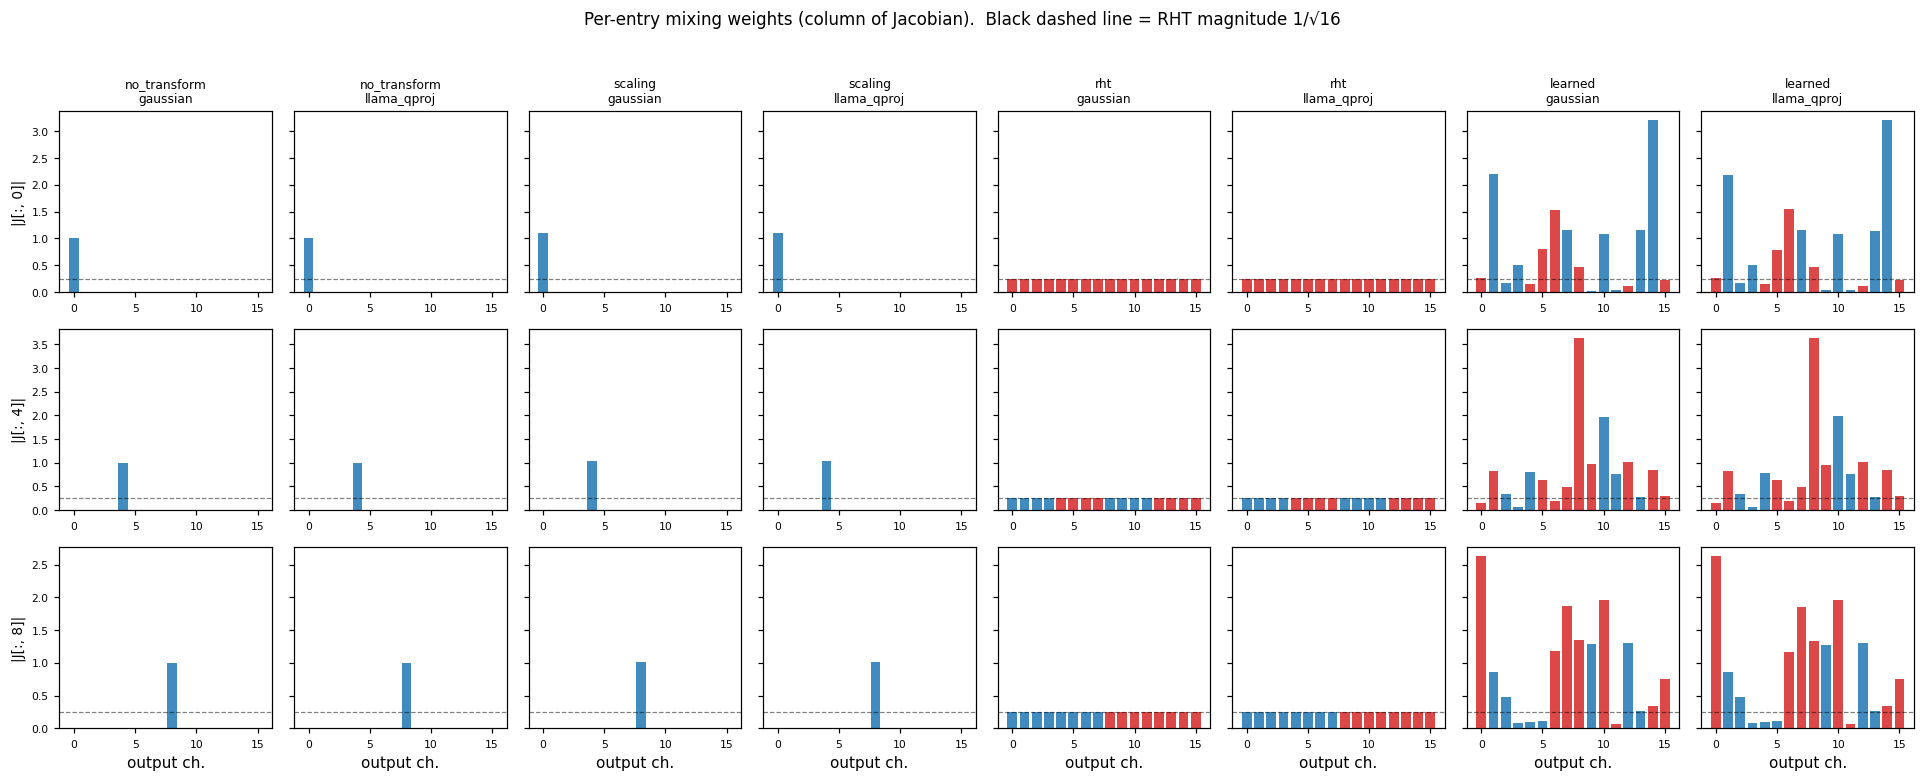

In [27]:
# 12. Per-entry channel mixing — bar chart of |J[:, i]| (one input dim, all 16 output channels)
INPUT_DIMS_VIZ = [0, 4, 8]                       # which input dims to visualize
RHT_REF = 1.0 / math.sqrt(BLOCK_DIM)             # |H_ij| = 1/√16 ≈ 0.25

fig, axes = plt.subplots(len(INPUT_DIMS_VIZ), n_rows*n_cols,
                         figsize=(2.2*n_rows*n_cols, 2.4*len(INPUT_DIMS_VIZ)), dpi=110, sharey='row')
for r, i_in in enumerate(INPUT_DIMS_VIZ):
    col = 0
    for tname in names_order:
        for ds in datasets:
            J = JACOBIANS[(ds, tname)]                       # (16, 16)
            entries = J[:, i_in].numpy()
            ax = axes[r, col]
            colors = ['tab:red' if e < 0 else 'tab:blue' for e in entries]
            ax.bar(np.arange(BLOCK_DIM), np.abs(entries), color=colors, alpha=0.85)
            ax.axhline(RHT_REF, color='black', ls='--', alpha=0.5, linewidth=0.8)
            if r == 0:
                ax.set_title(f'{tname}\n{ds}', fontsize=8)
            if col == 0:
                ax.set_ylabel(f'|J[:, {i_in}]|', fontsize=9)
            ax.set_xlabel('output ch.' if r == len(INPUT_DIMS_VIZ)-1 else '')
            ax.tick_params(labelsize=7)
            col += 1
fig.suptitle('Per-entry mixing weights (column of Jacobian).  Black dashed line = RHT magnitude 1/√16', fontsize=11)
fig.tight_layout(rect=[0, 0, 1, 0.96])
fig.savefig(FIG_DIR / 'fig12_per_entry_mixing.png'); plt.show()


## 13. Random-init NWC vs trained learned: how close to RHT? (Figure 7)

Instantiate a fresh **randomly-initialized** NWC of the same architecture (no checkpoint loaded).
Then compare the trained `learned` encoder against this `random_init` baseline using the
RHT-similarity metrics:

- **ortho_rel** = $\lVert J^TJ - \alpha I\rVert / \lVert\alpha I\rVert$ — closer to 0 ⇒ orthogonal
- **m2m_med** = median(row max / row mean of $|J|$) — RHT $\to 1.0$, identity $\to 16$
- **pr_med** = median participation ratio across input dims — RHT $\to 16$, identity $\to 1$
- **|J|-Frobenius distance to RHT**: $\lVert\,|J| - |J_\text{RHT}|\,\rVert_F / \lVert J_\text{RHT}\rVert_F$

If the trained encoder is significantly closer to RHT than the random-init baseline,
that's evidence training pushed it toward Hadamard-like behavior.

In [28]:
# 13a. Instantiate random-initialized NWC, compute its Jacobian + metrics.
import copy as _copy

def make_random_nwc(reference_model, seed=42):
    """Fresh NWC with same architecture but random weights (no checkpoint)."""
    cfg = _copy.deepcopy(reference_model.config)
    scale, shift = torch.ones(1), torch.zeros(1)
    torch.manual_seed(seed)
    m = get_model(cfg.architecture, cfg, scale=scale, shift=shift)
    try:    m.scale.copy_(scale); m.shift.copy_(shift)
    except: m.scale = scale; m.shift = shift
    return m.eval().to(DEVICE)

nwc_random = make_random_nwc(nwc, seed=42)
TRANSFORMS['random_init'] = make_learned_transform(nwc_random, q_level=Q_LEVEL)

# extend names_order, recompute Jacobians + metrics for the new transform only
if 'random_init' not in names_order:
    names_order.append('random_init')
n_rows = len(names_order)

for ds_name, X in DATASETS.items():
    anchor = X[0].clone()
    tf = TRANSFORMS['random_init']
    J = jacobian_full(tf, anchor)
    JACOBIANS[(ds_name, 'random_init')] = J.detach().cpu()
    with torch.no_grad():
        X_out = tf(X)
    RESULTS[(ds_name, 'random_init')] = {
        'orthogonality': orthogonality_metric(J),
        'entries':       entry_distribution_metric(J),
        'energy':        energy_mixing_metric(J),
        'covariance':    covariance_metrics(X, X_out),
    }

# Print the same kind of table for visual comparison
print(f'{"dataset":12s} | {"transform":<14s} | ortho_rel  m2m_med  pr_med   cond_post')
for ds in datasets:
    for tname in names_order:
        m = RESULTS[(ds, tname)]
        print(f'{ds:12s} | {tname:<14s} | {m["orthogonality"]["frob_diff_rel"]:8.3f}   '
              f'{m["entries"]["max_to_mean_median"]:6.2f}   {m["energy"]["participation_median"]:5.2f}    '
              f'{m["covariance"]["post"]["cond"]:.2e}')


dataset      | transform      | ortho_rel  m2m_med  pr_med   cond_post
gaussian     | no_transform   |    0.000    16.00    1.00    1.19e+00
gaussian     | scaling        |    0.081    16.00    1.00    1.40e+00
gaussian     | rht            |    0.000     1.00   16.00    1.19e+00
gaussian     | learned        |    0.015     3.97    7.58    1.20e+00
gaussian     | random_init    |    1.351     2.66   11.16    1.36e+02
llama_qproj  | no_transform   |    0.000    16.00    1.00    1.43e+00
llama_qproj  | scaling        |    0.081    16.00    1.00    1.24e+00
llama_qproj  | rht            |    0.000     1.00   16.00    1.43e+00
llama_qproj  | learned        |    0.015     3.97    7.58    1.43e+00
llama_qproj  | random_init    |    1.548     2.37   10.93    1.21e+02


RHT-similarity metrics (smaller dist_to_RHT = closer to RHT):
    dataset    transform  ortho_rel  m2m_median  participation_median  dist_to_RHT
   gaussian no_transform   0.000000   16.000000              1.000000     1.224745
   gaussian      scaling   0.081298   16.000000              1.000000     1.229771
   gaussian          rht   0.000000    1.000000             16.000000     0.000000
   gaussian      learned   0.014894    3.969304              7.575772     4.132152
   gaussian  random_init   1.351242    2.662624             11.162323     6.486548
llama_qproj no_transform   0.000000   16.000000              1.000000     1.224745
llama_qproj      scaling   0.081298   16.000000              1.000000     1.229771
llama_qproj          rht   0.000000    1.000000             16.000000     0.000000
llama_qproj      learned   0.015026    3.965926              7.575771     4.129318
llama_qproj  random_init   1.548245    2.367200             10.926664     7.361388


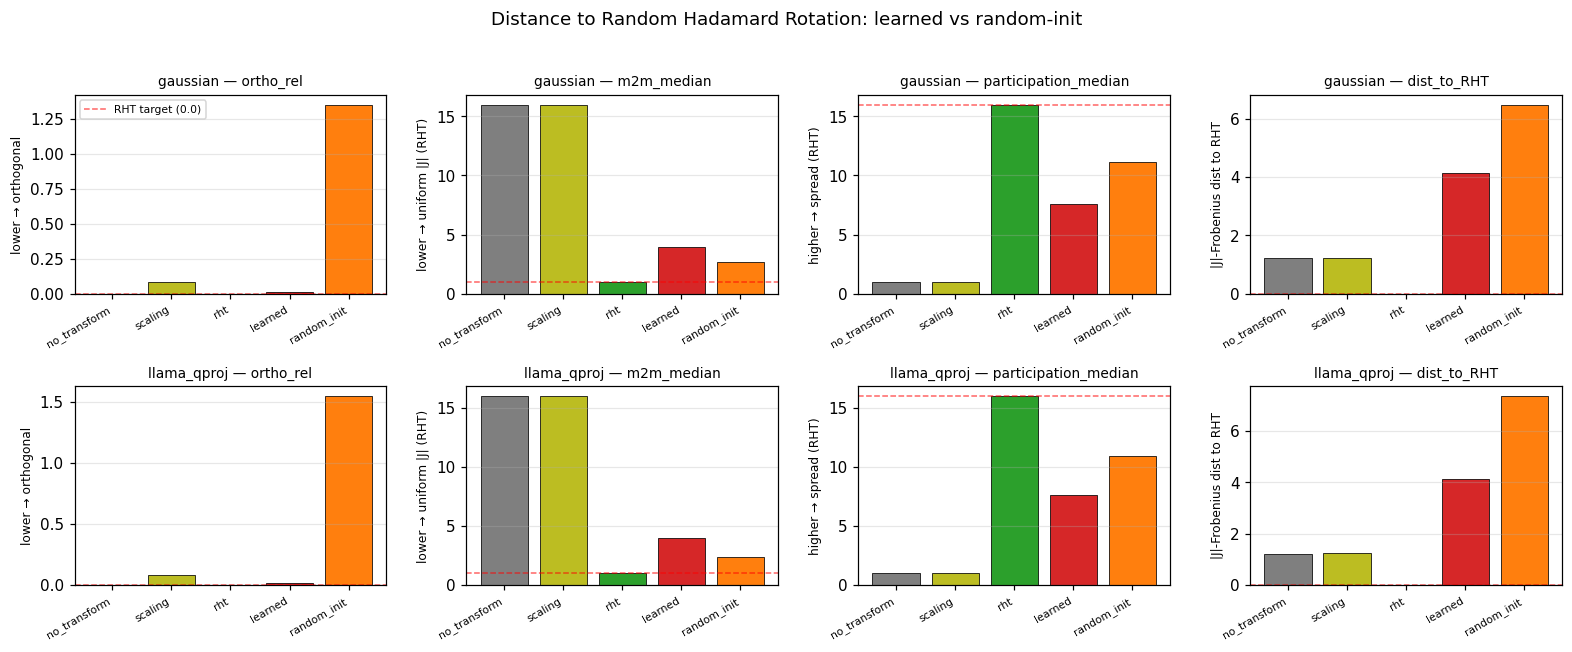

In [29]:
# 13b. Distance-to-RHT bar chart  +  4-metric comparison across all transforms
def J_distance_to_rht(J, J_rht, sign_invariant=True):
    """Frobenius distance, normalized by ‖J_rht‖.  sign_invariant=True compares |J|."""
    if sign_invariant:
        return float(torch.linalg.norm(J.abs() - J_rht.abs()) / torch.linalg.norm(J_rht))
    else:
        return float(torch.linalg.norm(J - J_rht) / torch.linalg.norm(J_rht))

# Add |J|-distance-to-RHT for every transform
DIST_RHT = {}
for ds in datasets:
    J_rht = JACOBIANS[(ds, 'rht')]
    for tname in names_order:
        DIST_RHT[(ds, tname)] = J_distance_to_rht(JACOBIANS[(ds, tname)], J_rht, sign_invariant=True)

# Update summary table
rows = []
for ds in datasets:
    for tname in names_order:
        m = RESULTS[(ds, tname)]
        rows.append({
            'dataset': ds, 'transform': tname,
            'ortho_rel': m['orthogonality']['frob_diff_rel'],
            'm2m_median': m['entries']['max_to_mean_median'],
            'participation_median': m['energy']['participation_median'],
            'dist_to_RHT': DIST_RHT[(ds, tname)],
        })
df_rht = pd.DataFrame(rows)
df_rht.to_csv(FIG_DIR / 'fig13_rht_similarity_table.csv', index=False)
print('RHT-similarity metrics (smaller dist_to_RHT = closer to RHT):')
display_cols = ['dataset', 'transform', 'ortho_rel', 'm2m_median', 'participation_median', 'dist_to_RHT']
print(df_rht[display_cols].to_string(index=False))

# 4-metric comparison plot — one row per dataset
metric_specs = [
    ('ortho_rel',            'lower → orthogonal',       0.0, 'min'),
    ('m2m_median',           'lower → uniform |J| (RHT)', 1.0, 'min'),
    ('participation_median', 'higher → spread (RHT)',    16.0, 'max'),
    ('dist_to_RHT',          '|J|-Frobenius dist to RHT', 0.0, 'min'),
]

fig, axes = plt.subplots(len(datasets), len(metric_specs),
                         figsize=(3.6*len(metric_specs), 3.0*len(datasets)), dpi=110)
if len(datasets) == 1: axes = axes[None, :]
color_map = {
    'no_transform': 'tab:gray', 'scaling': 'tab:olive',
    'rht':          'tab:green', 'random_init': 'tab:orange',
    'learned':      'tab:red',
}
for r, ds in enumerate(datasets):
    sub = df_rht[df_rht['dataset'] == ds].set_index('transform').reindex(names_order)
    for c, (metric, label, ref_val, _) in enumerate(metric_specs):
        ax = axes[r, c]
        vals = sub[metric].values
        bars = ax.bar(np.arange(len(names_order)), vals,
                      color=[color_map.get(t, 'C0') for t in names_order],
                      edgecolor='black', linewidth=0.5)
        ax.axhline(ref_val, color='red', ls='--', alpha=0.6, linewidth=1.0,
                   label=f'RHT target ({ref_val})')
        ax.set_xticks(np.arange(len(names_order)))
        ax.set_xticklabels(names_order, rotation=30, ha='right', fontsize=7)
        ax.set_title(f'{ds} — {metric}', fontsize=9)
        ax.set_ylabel(label, fontsize=8)
        ax.grid(True, axis='y', alpha=0.3)
        if r == 0 and c == 0: ax.legend(fontsize=7)
fig.suptitle('Distance to Random Hadamard Rotation: learned vs random-init', fontsize=12)
fig.tight_layout(rect=[0, 0, 1, 0.96])
fig.savefig(FIG_DIR / 'fig13_rht_similarity.png'); plt.show()


## 14. Data-driven (Jacobian-free) m2m & PR via cross-covariance

The Jacobian $J$ at one anchor is a **local** linear approximation of $T$.  A **global**
linear approximation can be computed from $(X, Z)$ pairs alone by ordinary least squares:
$$\hat J_\text{emp} = \Sigma_{zx}\,\Sigma_{xx}^{-1},\qquad
\Sigma_{zx} = \tfrac1N\sum_n (z^{(n)}-\bar z)(x^{(n)}-\bar x)^T,\;
\Sigma_{xx} = \tfrac1N\sum_n (x^{(n)}-\bar x)(x^{(n)}-\bar x)^T.$$
This is the matrix that minimizes $\sum_n \lVert z^{(n)} - \hat J_\text{emp}\,(x^{(n)}-\bar x)\rVert^2$.

- **Linear transforms** (id, scaling, RHT): $\hat J_\text{emp}$ recovers the true $J$ exactly.
- **Nonlinear transforms** (learned, random_init): $\hat J_\text{emp}$ is the best
  **global** linear approximation — averages over the input distribution rather than
  evaluating at one anchor.

Then apply `m2m_median` and `participation_median` to $|\hat J_\text{emp}|$ — same metrics,
**no gradient required.**


Anchor (gradient at X[0])  vs  Empirical (global OLS, no gradient):
    dataset    transform  m2m_anchor   m2m_emp  pr_anchor    pr_emp  ortho_anchor    ortho_emp  dist_anchor  dist_emp
   gaussian no_transform   16.000000 16.000000   1.000000  1.000000      0.000000 1.265803e-07     1.224745  1.224745
   gaussian      scaling   16.000000 16.000000   1.000000  1.000000      0.081298 8.129826e-02     1.229771  1.229771
   gaussian          rht    1.000000  1.000000  16.000000 16.000000      0.000000 3.326478e-07     0.000000  0.000000
   gaussian      learned    3.969304  3.986674   7.575772  7.530617      0.014894 1.548700e-02     4.132152  4.128796
   gaussian  random_init    2.662624  2.274254  11.162323 11.341695      1.351242 1.311469e+00     6.486548  3.580548
llama_qproj no_transform   16.000000 16.000000   1.000000  1.000000      0.000000 1.194102e-07     1.224745  1.224745
llama_qproj      scaling   16.000000 16.000000   1.000000  1.000000      0.081298 8.129816e-02     1.22977

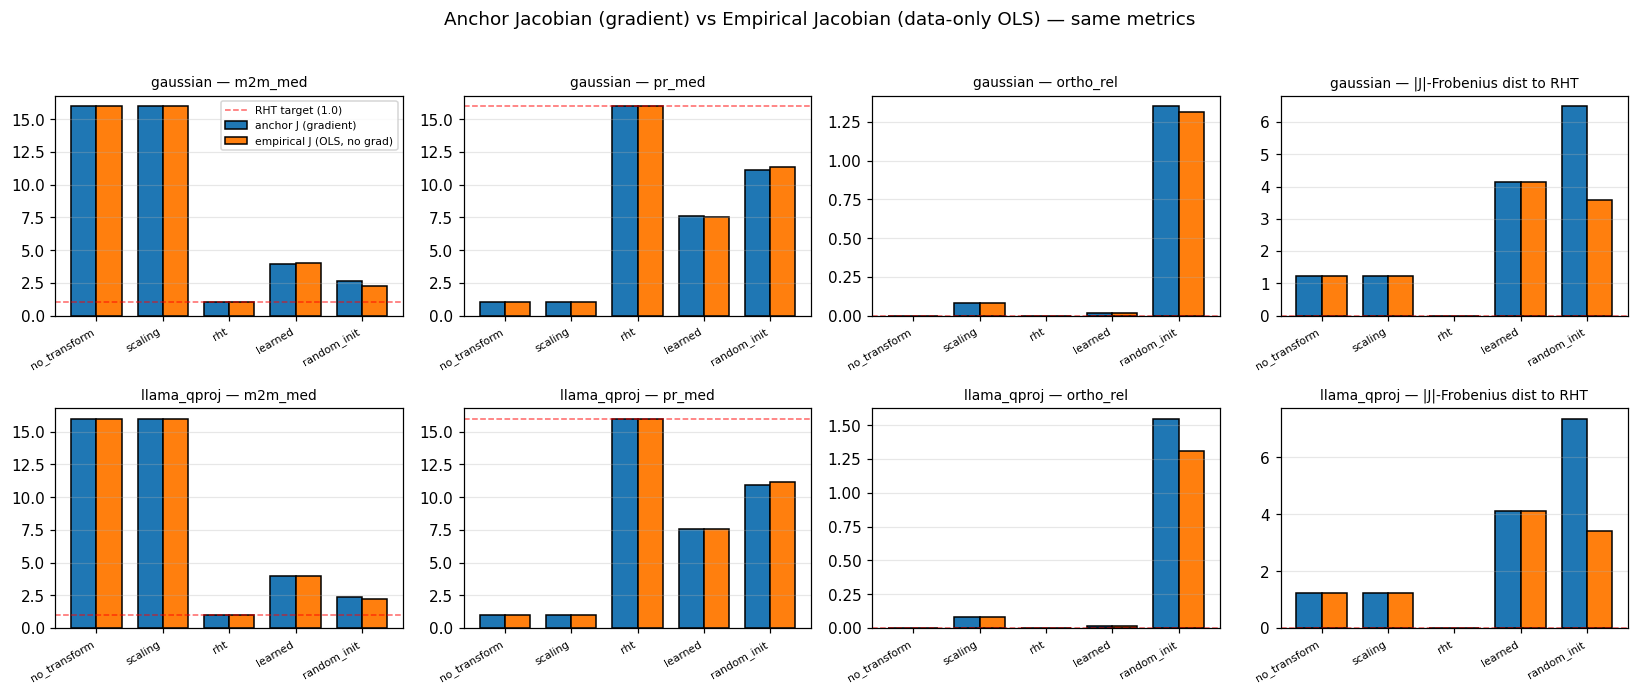

In [30]:
# 14. Data-driven empirical Jacobian via OLS regression  +  whitened-output orthogonality
@torch.no_grad()
def empirical_linear_jacobian(X: torch.Tensor, Z: torch.Tensor, eps: float = 1e-9):
    """Returns J_emp of shape (d_out, d_in) such that Z ≈ J_emp · (X − bar X) + bias.
       Computed as Σ_zx Σ_xx^{-1} (cross-covariance regression)."""
    Xc = X - X.mean(0, keepdim=True)
    Zc = Z - Z.mean(0, keepdim=True)
    N = X.shape[0]
    Sxx = Xc.T @ Xc / (N - 1) + eps * torch.eye(X.shape[1], device=X.device, dtype=X.dtype)
    Sxz = Xc.T @ Zc / (N - 1)
    return torch.linalg.solve(Sxx, Sxz).T

@torch.no_grad()
def orthogonality_emp_whitened(X: torch.Tensor, Z: torch.Tensor, eps: float = 1e-9):
    """Whitened-input output covariance test for J_emp J_emp^T = α I.
       Uses ONLY the (X, Z) pairs (no gradient, no model access)."""
    J_emp = empirical_linear_jacobian(X, Z, eps=eps)
    G = J_emp @ J_emp.T
    D = G.shape[0]
    alpha = float(torch.trace(G).item()) / D
    diff = G - alpha * torch.eye(D, device=G.device, dtype=G.dtype)
    return float(torch.linalg.norm(diff).item()) / max(
        float(torch.linalg.norm(alpha * torch.eye(D, device=G.device, dtype=G.dtype)).item()), 1e-12)

# Compute J_emp + metrics for every (dataset, transform)
JACOBIANS_EMP = {}
RESULTS_EMP   = {}
for ds_name, X in DATASETS.items():
    for tname, tf in TRANSFORMS.items():
        with torch.no_grad():
            Z = tf(X)
        J_emp = empirical_linear_jacobian(X, Z).detach().cpu()
        JACOBIANS_EMP[(ds_name, tname)] = J_emp
        RESULTS_EMP[(ds_name, tname)] = {
            "m2m":        entry_distribution_metric(J_emp)["max_to_mean_median"],
            "pr":         energy_mixing_metric(J_emp)["participation_median"],
            "orth_J":     orthogonality_metric(J_emp)["frob_diff_rel"],
            "orth_white": orthogonality_emp_whitened(X.cpu(), Z.cpu()),
        }

# Distance to RHT (using empirical Jacobian)
DIST_RHT_EMP = {}
for ds in datasets:
    J_rht_emp = JACOBIANS_EMP[(ds, "rht")]
    for tname in names_order:
        DIST_RHT_EMP[(ds, tname)] = float(
            torch.linalg.norm(JACOBIANS_EMP[(ds, tname)].abs() - J_rht_emp.abs())
            / torch.linalg.norm(J_rht_emp))

# Anchor vs empirical for all 4 metrics
rows = []
for ds in datasets:
    for tname in names_order:
        rows.append({
            "dataset": ds, "transform": tname,
            "m2m_anchor":   RESULTS[(ds, tname)]["entries"]["max_to_mean_median"],
            "m2m_emp":      RESULTS_EMP[(ds, tname)]["m2m"],
            "pr_anchor":    RESULTS[(ds, tname)]["energy"]["participation_median"],
            "pr_emp":       RESULTS_EMP[(ds, tname)]["pr"],
            "ortho_anchor": RESULTS[(ds, tname)]["orthogonality"]["frob_diff_rel"],
            "ortho_emp":    RESULTS_EMP[(ds, tname)]["orth_J"],
            "dist_anchor":  DIST_RHT[(ds, tname)],
            "dist_emp":     DIST_RHT_EMP[(ds, tname)],
        })
df_emp = pd.DataFrame(rows)
df_emp.to_csv(FIG_DIR / "fig14_anchor_vs_empirical.csv", index=False)
print("Anchor (gradient at X[0])  vs  Empirical (global OLS, no gradient):")
print(df_emp.to_string(index=False))

# 4-metric × N-dataset bar grid
fig, axes = plt.subplots(len(datasets), 4, figsize=(15, 3.2*len(datasets)), dpi=110)
if len(datasets) == 1: axes = axes[None, :]
xs = np.arange(len(names_order))
w  = 0.38
metric_specs = [
    ("m2m_anchor",   "m2m_emp",   "m2m_med",                   1.0),
    ("pr_anchor",    "pr_emp",    "pr_med",                    16.0),
    ("ortho_anchor", "ortho_emp", "ortho_rel",                 0.0),
    ("dist_anchor",  "dist_emp",  "|J|-Frobenius dist to RHT", 0.0),
]
for r, ds in enumerate(datasets):
    sub = df_emp[df_emp["dataset"] == ds].set_index("transform").reindex(names_order)
    for c, (col_a, col_e, label, ref) in enumerate(metric_specs):
        ax = axes[r, c]
        ax.bar(xs - w/2, sub[col_a], width=w, label="anchor J (gradient)",
               color="tab:blue", edgecolor="black")
        ax.bar(xs + w/2, sub[col_e], width=w, label="empirical J (OLS, no grad)",
               color="tab:orange", edgecolor="black")
        ax.axhline(ref, color="red", ls="--", alpha=0.6, linewidth=1.0,
                   label=f"RHT target ({ref})")
        ax.set_xticks(xs); ax.set_xticklabels(names_order, rotation=30, ha="right", fontsize=7)
        ax.set_title(f"{ds} — {label}", fontsize=9)
        ax.grid(True, axis="y", alpha=0.3)
        if r == 0 and c == 0: ax.legend(fontsize=7)
fig.suptitle("Anchor Jacobian (gradient) vs Empirical Jacobian (data-only OLS) — same metrics",
             fontsize=12)
fig.tight_layout(rect=[0, 0, 1, 0.96])
fig.savefig(FIG_DIR / "fig14_anchor_vs_empirical.png"); plt.show()


## 15. Multi-anchor Jacobian metrics — how anchor-dependent are the §5 numbers?

§5's `ortho_rel`, `m2m_med`, `pr_med` were computed from $J = \partial z/\partial x$ at a
**single anchor** $x = X[0]$. For linear transforms (id, scaling, RHT) this is exact since $J$
is constant. For nonlinear ones (learned, random_init), $J(x)$ varies with $x$.

We sample **K=64 random anchors** per dataset, compute $J$ at each, and report
the metric distribution (mean ± std). If std is small ⇒ §5's single-anchor number is reliable.


gaussian     | no_transform    ortho=0.000±0.000  m2m=16.00±0.00  pr=1.00±0.00
gaussian     | scaling         ortho=0.081±0.000  m2m=16.00±0.00  pr=1.00±0.00
gaussian     | rht             ortho=0.000±0.000  m2m=1.00±0.00  pr=16.00±0.00
gaussian     | learned         ortho=0.023±0.016  m2m=3.99±0.03  pr=7.54±0.06


gaussian     | random_init     ortho=1.475±0.140  m2m=2.45±0.13  pr=10.70±0.33
llama_qproj  | no_transform    ortho=0.000±0.000  m2m=16.00±0.00  pr=1.00±0.00
llama_qproj  | scaling         ortho=0.081±0.000  m2m=16.00±0.00  pr=1.00±0.00
llama_qproj  | rht             ortho=0.000±0.000  m2m=1.00±0.00  pr=16.00±0.00
llama_qproj  | learned         ortho=0.020±0.008  m2m=3.98±0.02  pr=7.53±0.06


W0507 10:48:47.964725 904228 warnings.py:109] /tmp/ipykernel_904228/1466907289.py:50: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, labels=names_order, showfliers=True, widths=0.55,



W0507 10:48:47.985883 904228 warnings.py:109] /tmp/ipykernel_904228/1466907289.py:50: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, labels=names_order, showfliers=True, widths=0.55,



W0507 10:48:48.002818 904228 warnings.py:109] /tmp/ipykernel_904228/1466907289.py:50: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, labels=names_order, showfliers=True, widths=0.55,



W0507 10:48:48.019593 904228 warnings.py:109] /tmp/ipykernel_904228/1466907289.py:50: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, labels=names_order, showfliers=True, widths=0.55,



W0507 10:48:48.037980 904228 warnings.py:109] /tmp/ipykernel_904228/1466907289.py:50: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, labels=names_order, showfliers=True, widths=0.55,



W0507 10:48:48.055181 904228 warnings.py:109] /tmp/ipykernel_904228/1466907289.py:50: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, labels=names_order, showfliers=True, widths=0.55,



llama_qproj  | random_init     ortho=1.463±0.117  m2m=2.47±0.15  pr=10.67±0.37


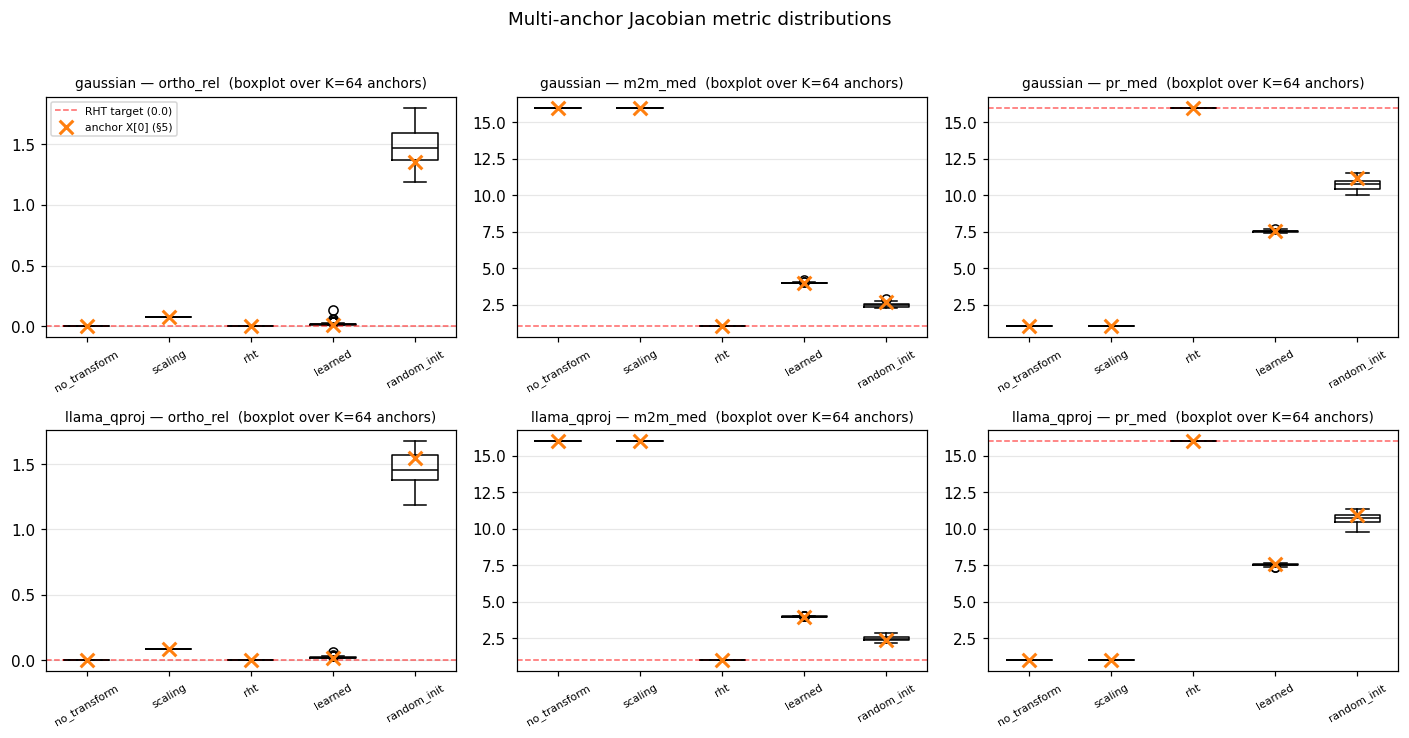

In [31]:
# 15. Multi-anchor Jacobian metric distribution.
K_ANCHORS = 64
g_anchor = torch.Generator().manual_seed(123)

def _metric_dict(J):
    return {
        "ortho": orthogonality_metric(J)["frob_diff_rel"],
        "m2m":   entry_distribution_metric(J)["max_to_mean_median"],
        "pr":    energy_mixing_metric(J)["participation_median"],
    }

MULTI_ANCHOR = {}
for ds_name, X in DATASETS.items():
    N = X.shape[0]
    anchor_idx = torch.randperm(N, generator=g_anchor)[:K_ANCHORS]
    for tname, tf in TRANSFORMS.items():
        if tname in ("no_transform", "scaling", "rht"):
            # J is constant in x; replicate single value
            anchor = X[0].clone()
            J = compute_jacobian(tname, tf, anchor).detach().cpu()
            m = _metric_dict(J)
            MULTI_ANCHOR[(ds_name, tname)] = {k: np.full(K_ANCHORS, v) for k, v in m.items()}
        else:
            # learned / random_init: re-compute J at each anchor
            ortho_list, m2m_list, pr_list = [], [], []
            for k in range(K_ANCHORS):
                anchor = X[anchor_idx[k]].clone()
                J = jacobian_full(tf, anchor).detach().cpu()
                m = _metric_dict(J)
                ortho_list.append(m["ortho"]); m2m_list.append(m["m2m"]); pr_list.append(m["pr"])
            MULTI_ANCHOR[(ds_name, tname)] = {
                "ortho": np.array(ortho_list),
                "m2m":   np.array(m2m_list),
                "pr":    np.array(pr_list),
            }
        m = MULTI_ANCHOR[(ds_name, tname)]
        print(f"{ds_name:12s} | {tname:14s}  "
              f"ortho={m['ortho'].mean():.3f}±{m['ortho'].std():.3f}  "
              f"m2m={m['m2m'].mean():.2f}±{m['m2m'].std():.2f}  "
              f"pr={m['pr'].mean():.2f}±{m['pr'].std():.2f}")

# Violin plot — metric distribution across K anchors per (ds, transform)
fig, axes = plt.subplots(len(datasets), 3, figsize=(13, 3.4*len(datasets)), dpi=110)
if len(datasets) == 1: axes = axes[None, :]
metric_specs = [("ortho", "ortho_rel", 0.0), ("m2m", "m2m_med", 1.0), ("pr", "pr_med", 16.0)]
for r, ds in enumerate(datasets):
    for c, (mkey, label, ref) in enumerate(metric_specs):
        ax = axes[r, c]
        data = [MULTI_ANCHOR[(ds, t)][mkey] for t in names_order]
        bp = ax.boxplot(data, labels=names_order, showfliers=True, widths=0.55,
                        medianprops=dict(color="black"))
        ax.axhline(ref, color="red", ls="--", alpha=0.6, linewidth=1.0,
                   label=f"RHT target ({ref})")
        # also mark §5 single-anchor value
        anchor_val = [RESULTS[(ds, t)]["orthogonality"]["frob_diff_rel"] if mkey=="ortho"
                      else RESULTS[(ds, t)]["entries"]["max_to_mean_median"]    if mkey=="m2m"
                      else RESULTS[(ds, t)]["energy"]["participation_median"]   for t in names_order]
        ax.scatter(np.arange(1, len(names_order)+1), anchor_val,
                   marker="x", s=80, color="tab:orange", linewidth=2,
                   label="anchor X[0] (§5)", zorder=5)
        ax.tick_params(axis="x", labelrotation=30, labelsize=7)
        ax.set_title(f"{ds} — {label}  (boxplot over K=64 anchors)", fontsize=9)
        ax.grid(True, axis="y", alpha=0.3)
        if r == 0 and c == 0: ax.legend(fontsize=7, loc="best")
fig.suptitle("Multi-anchor Jacobian metric distributions", fontsize=12)
fig.tight_layout(rect=[0, 0, 1, 0.96])
fig.savefig(FIG_DIR / "fig15_multi_anchor.png"); plt.show()
